# AI 면접관 Agent
- 내 서류와 경험을 다시 정리하고 → 그 경험을 바탕으로 질문하고 → 꼬리질문으로 깊게 파고들고 → 답변을 평가하고 피드백해주는 Agent

## 1. 환경 설정 및 라이브러리 로딩

In [136]:
# ============================================================
# 1. Python 기본 라이브러리
# ============================================================

import os
import json
import re

from pathlib import Path
from typing import (
    TypedDict,
    List,
    Dict,
    Literal,
    Optional,
    Any,
)


# ============================================================
# 2. 환경변수
# ============================================================

from dotenv import load_dotenv


# ============================================================
# 3. 데이터 Schema
# ============================================================

from pydantic import BaseModel, Field


# ============================================================
# 4. LangChain / OpenAI
# ============================================================

from langchain_openai import ChatOpenAI

from langchain_core.prompts import ChatPromptTemplate


# ============================================================
# 5. LangGraph
# ============================================================

from langgraph.graph import (
    StateGraph,
    START,
    END,
)

from langgraph.checkpoint.memory import InMemorySaver

from langgraph.types import (
    Command,
    interrupt,
)


# ============================================================
# 6. 환경변수 로드
# ============================================================

load_dotenv()

True

## 2. Interview State 설계

### 목적
- 각 Node의 입출력과 면접 진행 상태를 하나의 State로 관리
- 질문 → 답변 → 평가 → Router의 반복 흐름을 위한 정보 저장

### 입출력
- **입력** : 이력서/자기소개서, 채용공고
- **출력** : 최종 면접 피드백

### 처리
- 각 Node가 필요한 정보를 State에서 가져와 처리
- Node 처리 결과를 다시 State에 저장
- 답변 평가 결과에 따라 `FOLLOW_UP / NEXT / END` 흐름 관리

### State 관리 정보
- 입력 : 서류, 채용공고
- 분석 : 파싱 결과, 지원자/JD 분석
- 면접 준비 : RAG 결과, 면접 전략
- 인터뷰 : 현재 질문/답변, 질문·답변 기록
- 평가 : 답변 평가 결과
- 진행 상태 : `FOLLOW_UP / NEXT / END`
- 결과 : 최종 피드백

In [137]:
from typing import TypedDict, List, Dict, Literal, Optional


class InterviewState(TypedDict, total=False):

    # ==================================================
    # 1. 사용자 입력
    # input_collection
    # ==================================================

    resume_file_path: str
    job_posting_url: str


    # ==================================================
    # 2. 문서 파싱
    # document_parsing / parsing_validation
    # ==================================================

    resume_text: str
    job_description_text: str

    parsing_status: Literal["PENDING", "PASS", "FAIL"]
    parsing_error: Optional[str]
    parsing_retry_count: int

    resume_parsing_status: Literal["PENDING", "PASS", "FAIL"]
    job_parsing_status: Literal["PENDING", "PASS", "FAIL"]

    resume_parsing_error: Optional[str]
    job_parsing_error: Optional[str]


    # ==================================================
    # 3. 서류 / 채용공고 분석
    # candidate_jd_analysis
    # ==================================================

    candidate_profile: Dict[str, Any]
    jd_analysis: Dict[str, Any]


    # ==================================================
    # 4. RAG 검색 결과
    # rag_retrieval
    # ==================================================

    retrieved_knowledge: List[Dict]


    # ==================================================
    # 5. 면접 전략
    # interview_strategy
    # ==================================================

    interview_strategy: Dict
    target_competencies: List[str]


    # ==================================================
    # 6. 현재 인터뷰 상태
    # question_generation / user_answer
    # ==================================================

    current_question: str
    current_answer: str

    current_competency: str

    question_type: Literal[
        "INITIAL",
        "FOLLOW_UP",
        "NEXT"
    ]


    # ==================================================
    # 7. 인터뷰 기록
    # ==================================================

    interview_history: List[Dict]

    question_count: int
    followup_count: int


    # ==================================================
    # 8. 답변 평가
    # answer_evaluation
    # ==================================================

    current_evaluation: Dict
    evaluation_history: List[Dict]


    # ==================================================
    # 9. 인터뷰 진행 판단
    # interview_router
    # ==================================================

    route: Literal[
        "FOLLOW_UP",
        "NEXT",
        "END"
    ]

    end_reason: Optional[str]


    # ==================================================
    # 10. 최종 결과
    # final_feedback
    # ==================================================

    final_feedback: Dict

## 3. 문서 파싱 설계

### 목적
- 서로 다른 구조의 서류와 채용공고에서 분석에 필요한 Text를 손실 없이 추출

### 입출력
- **입력** : 이력서/자기소개서 PDF, 채용공고 URL
- **출력** : 서류 Text, 채용공고 Text

### 처리
- PDF의 페이지/표/본문 Text 추출
- 채용공고 URL에서 실제 공고 본문 추출
- 불필요한 UI·메뉴·개인정보 등 제거
- 이후 분석 Node에서 활용할 수 있도록 Text 구조 정리

### 관리 정보
- `resume_file_path`
- `job_posting_url`
- `resume_text`
- `job_description_text`
- `parsing_error`

### 비고
- **PDF** : 페이지별 본문 Text를 추출하고 페이지 번호를 함께 저장한다. 표는 별도 구조로 추출하지 않으며, PDF의 Text Layer에 포함된 경우 일반 Text 형태로 추출된다. 이미지와 스캔 문서는 현재 추출하지 않는다.
- **사람인 URL** : 회사명, 공고명, 채용공고 상세 본문을 추출한다. 기본 상세 페이지 추출 실패 시 모바일 페이지를 사용한다.
- **원티드 URL** : 회사명, 포지션명, 회사·팀 소개, 주요 업무, 자격 요건, 우대 사항, 혜택, 기술 태그, 근무 지역 및 채용 전형 안내를 추출한다.
- 공통으로 메뉴·버튼·스크립트 등의 UI Text를 제거하고 이메일과 전화번호는 마스킹한다.

In [138]:
# ============================================================
# 3-1. 문서 파싱 공통 설정
# ============================================================

import re
from urllib.parse import parse_qs, urlparse

import requests
from bs4 import BeautifulSoup
from pypdf import PdfReader


CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

COMMON_HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    ),
    "Accept-Language": "ko-KR,ko;q=0.9,en-US;q=0.8",
}


def resolve_project_path(file_path: str | Path) -> Path:
    """상대 경로를 프로젝트 루트 기준의 절대 경로로 변환한다."""
    path = Path(file_path).expanduser()
    if not path.is_absolute():
        path = PROJECT_ROOT / path
    return path.resolve()


def normalize_text(text: str) -> str:
    """공백과 빈 줄을 정리하되 문단 구조는 유지한다."""
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = text.replace("\xa0", " ").replace("\u200b", "")

    cleaned_lines = []
    previous_blank = False

    for raw_line in text.split("\n"):
        line = re.sub(r"[ \t]+", " ", raw_line).strip()
        if line:
            cleaned_lines.append(line)
            previous_blank = False
        elif cleaned_lines and not previous_blank:
            cleaned_lines.append("")
            previous_blank = True

    return "\n".join(cleaned_lines).strip()


def redact_personal_info(text: str) -> str:
    """면접 분석에 불필요한 이메일과 휴대전화 번호를 마스킹한다."""
    text = re.sub(
        r"[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}",
        "[이메일 제거]",
        text,
    )
    text = re.sub(
        r"(?<!\d)01[016789][- .]?\d{3,4}[- .]?\d{4}(?!\d)",
        "[전화번호 제거]",
        text,
    )
    return text


print(f"PROJECT_ROOT: {PROJECT_ROOT}")

PROJECT_ROOT: c:\Users\USER\Desktop\Askly


In [139]:
# ============================================================
# 3-2. 이력서 PDF 파싱
# ============================================================

def parse_resume_pdf(file_path: str | Path) -> Dict[str, Any]:
    """
    PDF에서 페이지별 텍스트를 추출하고 분석용 텍스트로 정리한다.

    스캔 이미지로만 구성된 PDF는 별도의 OCR 처리가 필요하다.
    """
    path = resolve_project_path(file_path)

    if not path.exists():
        raise FileNotFoundError(f"PDF 파일을 찾을 수 없습니다: {path}")
    if path.suffix.lower() != ".pdf":
        raise ValueError(f"PDF 파일만 지원합니다: {path.name}")

    try:
        reader = PdfReader(str(path))
    except Exception as exc:
        raise RuntimeError(f"PDF를 열지 못했습니다: {exc}") from exc

    if reader.is_encrypted:
        try:
            decrypt_result = reader.decrypt("")
        except Exception as exc:
            raise ValueError("암호화된 PDF는 파싱할 수 없습니다.") from exc
        if decrypt_result == 0:
            raise ValueError("암호화된 PDF는 파싱할 수 없습니다.")

    page_blocks = []
    page_errors = []

    for page_number, page in enumerate(reader.pages, start=1):
        try:
            page_text = normalize_text(page.extract_text() or "")
        except Exception as exc:
            page_errors.append(f"{page_number}페이지: {exc}")
            continue

        if page_text:
            page_blocks.append(f"[PAGE {page_number}]\n{page_text}")

    resume_text = redact_personal_info("\n\n".join(page_blocks))

    if len(resume_text.strip()) < 30:
        raise ValueError(
            "PDF에서 충분한 텍스트를 추출하지 못했습니다. "
            "스캔 PDF라면 OCR 처리가 필요합니다."
        )

    return {
        "source_type": "PDF",
        "file_path": str(path),
        "file_name": path.name,
        "page_count": len(reader.pages),
        "text_length": len(resume_text),
        "page_errors": page_errors,
        "text": resume_text,
    }

In [140]:
# ============================================================
# 3-3. PDF 파싱 실행 테스트
# ============================================================

pdf_test_path = PROJECT_ROOT / "data" / "incrut_sample.pdf"
pdf_result = parse_resume_pdf(pdf_test_path)

assert pdf_result["page_count"] > 0
assert len(pdf_result["text"]) >= 30

print("=== [PDF 파싱 성공] ===")
print(f"파일: {pdf_result['file_name']}")
print(f"페이지 수: {pdf_result['page_count']}")
print(f"추출 글자 수: {pdf_result['text_length']}")
print("\n--- 추출 결과 미리보기 ---")
print(pdf_result["text"][:800])

=== [PDF 파싱 성공] ===
파일: incrut_sample.pdf
페이지 수: 3
추출 글자 수: 2856

--- 추출 결과 미리보기 ---
[PAGE 1]
입 사 지 원 서
■ 기본사항

성명
( 한글 ) 배수한 ( 영문 ) baesuhan 생년월일 1999.04.03 연락처 [전화번호 제거] 이메일 [이메일 제거] 주소 인주대로 662 번길 32( 구월 1 동 , 팬더아파트 6 동 109 호 ) ■ 학력 및 경력사항 학 력 사 항
학 교 명 전 공 입학년도 졸업년도 졸업여부 동양미래대학교 인공지능소프트웨어학과 2025.03 2026.02 졸업 동양미래 ( 전문 ) 대학교 인공지능소프트웨어학과 2022.03 2025.02 졸업 인천기계공업고등학교 정밀기계 2016.03 2018.02 졸업 ■ 자격 및 특기사항 날짜 자격증 점수 / 급수 발급기관 2025.05.19 AICE Associate - KT, 한국경제신문 2024.09.10 정보처리산업기사 - 한국산업인력공단 2023.09.15 ADSP - 한국데이터산업진흥원 ■ 대외활동 기간 활동내용 발급기관 비고 2025.09 ~ 2026.03 KT 에이블스쿨 KT 수료 2025.02 ~ 2025.06 고려대학교 지능정보 SW 아카데미
고려대학교 수료

취업비서 인크루트에서 무료로 제공하는 자료입니다 .

[PAGE 2]
■ 자기소개서
성 장 과 정
[ 구현을 넘어 문제 정의와 검증으로 ] 저는 새로운 AI 기술을 학습하고 , 이를 실제로 동작하는 서비스로 연결해 온 개발자입니다 . 고려대학교 지능정보 SW 아카데미에서는 3D 재구성 관련 논문과 모델을 탐색하고 직접 적용하며 , 새로운 기술을 빠르게 이해해 필요한 기능으로 구현하는 역량을 키웠습니다 . 단순히 모델을 사용하는 데 그치지 않고 , 문제


In [141]:
# ============================================================
# 3-4. 사람인 채용공고 URL 파싱
# ============================================================

def extract_saramin_rec_idx(url: str) -> str:
    """사람인 URL의 rec_idx 값을 추출한다."""
    parsed = urlparse(url)
    rec_idx = parse_qs(parsed.query).get("rec_idx", [None])[0]

    if not rec_idx:
        match = re.search(r"rec_idx=(\d+)", url)
        rec_idx = match.group(1) if match else None

    if not rec_idx or not rec_idx.isdigit():
        raise ValueError("사람인 URL에서 rec_idx 값을 찾을 수 없습니다.")

    return rec_idx


def parse_saramin_job(url: str, timeout: int = 15) -> Dict[str, Any]:
    """
    사람인 메인 페이지에서 회사명/공고명을 가져오고,
    view-detail 본문을 우선 사용한 뒤 모바일 페이지를 폴백으로 사용한다.
    """
    rec_idx = extract_saramin_rec_idx(url)
    main_url = f"https://www.saramin.co.kr/zf_user/jobs/relay/view?rec_idx={rec_idx}"
    detail_url = f"https://www.saramin.co.kr/zf_user/jobs/relay/view-detail?rec_idx={rec_idx}"
    mobile_url = f"https://m.saramin.co.kr/job-search/job-detail?rec_idx={rec_idx}"

    session = requests.Session()
    session.headers.update(COMMON_HEADERS)
    session.headers.update({"Referer": main_url})

    company_name = "회사명 미상"
    position = "공고명 미상"
    raw_body = ""
    parsed_from = ""

    try:
        main_response = session.get(main_url, timeout=timeout)
        if main_response.ok:
            main_soup = BeautifulSoup(main_response.text, "html.parser")
            og_title = main_soup.select_one("meta[property='og:title']")
            if og_title and og_title.get("content"):
                title_text = og_title["content"].replace(" - 사람인", "").strip()
                title_match = re.match(r"^\[(.*?)\]\s*(.*)$", title_text)
                if title_match:
                    company_name = title_match.group(1).strip()
                    position = title_match.group(2).strip()
                else:
                    position = title_text
    except requests.RequestException:
        # 본문 엔드포인트가 살아 있을 수 있으므로 계속 진행한다.
        pass

    try:
        detail_response = session.get(detail_url, timeout=timeout)
        if detail_response.ok:
            detail_soup = BeautifulSoup(detail_response.text, "html.parser")
            for tag in detail_soup.select("script, style, iframe, noscript, svg"):
                tag.decompose()
            detail_root = detail_soup.body or detail_soup
            raw_body = normalize_text(
                detail_root.get_text(separator="\n", strip=True)
            )
            parsed_from = detail_url
    except requests.RequestException:
        raw_body = ""

    if len(raw_body) < 100:
        try:
            mobile_response = session.get(mobile_url, timeout=timeout)
            mobile_response.raise_for_status()
            mobile_soup = BeautifulSoup(mobile_response.text, "html.parser")
            for tag in mobile_soup.select(
                "script, style, iframe, noscript, svg, header, footer, nav, button"
            ):
                tag.decompose()

            mobile_root = (
                mobile_soup.select_one(".detail_area")
                or mobile_soup.select_one(".job_detail")
                or mobile_soup.select_one("main")
            )
            if mobile_root:
                raw_body = normalize_text(
                    mobile_root.get_text(separator="\n", strip=True)
                )
                parsed_from = mobile_url
        except requests.RequestException as exc:
            raise RuntimeError(f"사람인 공고 요청에 실패했습니다: {exc}") from exc

    if len(raw_body) < 100:
        raise ValueError(
            "사람인 공고 본문을 충분히 추출하지 못했습니다. "
            "공고가 종료되었거나 페이지 구조가 변경되었는지 확인하세요."
        )

    raw_body = redact_personal_info(raw_body)
    full_text = normalize_text(
        f"# [{company_name}] {position}\n\n{raw_body}"
    )

    return {
        "source_type": "URL",
        "platform": "Saramin",
        "source_url": main_url,
        "parsed_from": parsed_from,
        "rec_idx": rec_idx,
        "company_name": company_name,
        "position": position,
        "text_length": len(full_text),
        "text": full_text,
    }

In [142]:
# ============================================================
# 3-5. 사람인 URL 파싱 실행 테스트
# ============================================================

saramin_test_url = (
    "https://www.saramin.co.kr/zf_user/jobs/relay/view?rec_idx=54940771"
)
saramin_result = parse_saramin_job(saramin_test_url)

assert saramin_result["platform"] == "Saramin"
assert len(saramin_result["text"]) >= 100

print("=== [사람인 URL 파싱 성공] ===")
print(f"회사명: {saramin_result['company_name']}")
print(f"공고명: {saramin_result['position']}")
print(f"추출 위치: {saramin_result['parsed_from']}")
print(f"추출 글자 수: {saramin_result['text_length']}")
print("\n--- 추출 결과 미리보기 ---")
print(saramin_result["text"][:800])

=== [사람인 URL 파싱 성공] ===
회사명: 파이특허법률사무소
공고명: [채용] 파이특허법률사무소 AI Transformation Team Intern(D-26)
추출 위치: https://www.saramin.co.kr/zf_user/jobs/relay/view-detail?rec_idx=54940771
추출 글자 수: 1600

--- 추출 결과 미리보기 ---
# [파이특허법률사무소] [채용] 파이특허법률사무소 AI Transformation Team Intern(D-26)

[채용] 파이특허법률사무소 AI Transformation Team Intern
AX TF Team Intern
(0명)
📋 주요업무
파이특허는 국내에서 가장 빠르게 성장하고 있는 특허사무소 중 하나입니다. 사내 AI 전환을 주도하는 AI Transformation(AX) TF Team에서 인턴을 찾고 있습니다.
■ 부서소개
파이특허 AI Transformation(AX) TF Team은 조직의 AI 전환을 주도하는 팀입니다. AI 관련 최신 트렌드와 기술 표준을 조사하고 실무에 적용하는 과정을 통해 회사에 맞는 AI 활용 방식을 정립하여 구성원들이 반복 업무 대신 판단이 필요한 일에 집중할 수 있도록 만드는 것이 TF 팀의 목표입니다.
■ 이런 일을 하게 됩니다
AI 관련 새로운 개념·기술을 리서치하고 실제 시스템에 반영될 수 있도록 구현합니다. 구성원들과 방향을 함께 고민하며 과제를 구체화하고 협업을 통해 결과물로 만들어냅니다.
• 리서치: AI 관련 최신 트렌드와 기술 표준을 조사합니다.
• 실험 & 검증: AI 기술을 실제 현업 프로세스에 대입하고, 전략을 수립합니다.
• 자산화: 사내에 필요한 AI 활용 기준을 문서나 가이드라인으로 정리해 구성원들이 참고할 수 있도록 합니다.
• 협업 & 확산: 개발자와의 협업을 통해 AI 솔루션 적용을 돕고, 실제 시스템이나 사내 규정으로 자리잡을 수 있도록 지원합니다.
■ 이런 분을 찾습니다
• 반복되는 작업이나 비효율적인 과정을

In [143]:
# ============================================================
# 3-6. 원티드 채용공고 URL 파싱
# ============================================================

def extract_wanted_job_id(url: str) -> str:
    """원티드 URL의 공고 ID를 추출한다."""
    match = re.search(r"/wd/(\d+)", urlparse(url).path)
    if not match:
        raise ValueError("원티드 URL에서 공고 ID를 찾을 수 없습니다.")
    return match.group(1)


def _tag_titles(tags: list) -> List[str]:
    """문자열 또는 객체 형태의 원티드 태그를 문자열 목록으로 변환한다."""
    titles = []
    for tag in tags or []:
        if isinstance(tag, str):
            title = tag
        elif isinstance(tag, dict):
            title = tag.get("title") or tag.get("name")
        else:
            title = None
        if title:
            titles.append(str(title).strip())
    return titles


def parse_wanted_job(url: str, timeout: int = 15) -> Dict[str, Any]:
    """원티드 API의 핵심 공고 정보와 웹 페이지의 추가 안내를 통합한다."""
    job_id = extract_wanted_job_id(url)
    api_url = f"https://www.wanted.co.kr/api/v4/jobs/{job_id}"
    web_url = f"https://www.wanted.co.kr/wd/{job_id}"

    session = requests.Session()
    session.headers.update(COMMON_HEADERS)

    try:
        api_response = session.get(api_url, timeout=timeout)
        api_response.raise_for_status()
        payload = api_response.json()
    except (requests.RequestException, ValueError) as exc:
        raise RuntimeError(f"원티드 API 호출에 실패했습니다: {exc}") from exc

    job_data = payload.get("job", payload)
    detail = job_data.get("detail") or {}
    company = job_data.get("company") or {}

    company_name = company.get("name") or "회사명 미상"
    position = job_data.get("position") or "공고명 미상"
    skills = _tag_titles(job_data.get("skill_tags") or [])
    company_tags = _tag_titles(job_data.get("company_tags") or [])

    address_data = job_data.get("address") or {}
    if isinstance(address_data, dict):
        address = (
            address_data.get("full_location")
            or address_data.get("location")
            or ""
        )
    else:
        address = str(address_data)

    extra_guide = ""
    try:
        web_response = session.get(web_url, timeout=timeout)
        if web_response.ok:
            web_soup = BeautifulSoup(web_response.text, "html.parser")
            for tag in web_soup.select(
                "header, footer, nav, script, style, iframe, noscript, svg, button"
            ):
                tag.decompose()

            page_text = normalize_text(
                web_soup.get_text(separator="\n", strip=True)
            )
            start_keywords = ["채용 전형", "꼭 확인해 주세요", "서류 작성 팁"]
            start_positions = [
                page_text.find(keyword)
                for keyword in start_keywords
                if page_text.find(keyword) >= 0
            ]

            if start_positions:
                sliced_text = page_text[min(start_positions):]
                end_keywords = [
                    "이 포지션을 찾고 계셨나요",
                    "비슷한 포지션",
                    "원티드랩",
                    "©",
                ]
                end_positions = [
                    sliced_text.find(keyword)
                    for keyword in end_keywords
                    if sliced_text.find(keyword) >= 0
                ]
                end_position = min(end_positions) if end_positions else len(sliced_text)
                extra_guide = sliced_text[:end_position].strip()
    except requests.RequestException:
        # API 핵심 본문이 있으므로 웹 페이지의 부가 안내 실패는 허용한다.
        pass

    full_text = f"""# [{company_name}] {position}

## 회사 및 팀 소개
{detail.get('intro') or '정보 없음'}

## 주요 업무
{detail.get('main_tasks') or '정보 없음'}

## 자격 요건
{detail.get('requirements') or '정보 없음'}

## 우대 사항
{detail.get('preferred_points') or '정보 없음'}

## 혜택 및 복지
{detail.get('benefits') or '정보 없음'}

## 채용 전형 및 서류 작성 팁
{extra_guide or '별도 상세 안내 없음'}

## 기업 및 기술 태그
- 요구/관련 스킬: {', '.join(skills) if skills else '정보 없음'}
- 기업 복지/문화 태그: {', '.join(company_tags) if company_tags else '정보 없음'}
- 근무 지역: {address or '정보 없음'}
"""

    full_text = redact_personal_info(normalize_text(full_text))
    if len(full_text) < 100:
        raise ValueError("원티드 공고 본문을 충분히 추출하지 못했습니다.")

    return {
        "source_type": "URL",
        "platform": "Wanted",
        "source_url": web_url,
        "parsed_from": api_url,
        "job_id": job_id,
        "company_name": company_name,
        "position": position,
        "text_length": len(full_text),
        "text": full_text,
    }


def parse_job_posting(url: str, timeout: int = 15) -> Dict[str, Any]:
    """URL 도메인에 따라 지원하는 채용공고 파서를 선택한다."""
    hostname = (urlparse(url).hostname or "").lower()

    if hostname.endswith("saramin.co.kr"):
        return parse_saramin_job(url, timeout=timeout)
    if hostname.endswith("wanted.co.kr"):
        return parse_wanted_job(url, timeout=timeout)

    raise ValueError("현재 지원하는 채용공고 URL은 사람인과 원티드입니다.")

In [144]:
# ============================================================
# 3-7. 원티드 URL 파싱 실행 테스트
# ============================================================

wanted_test_url = "https://www.wanted.co.kr/wd/375823"
wanted_result = parse_wanted_job(wanted_test_url)

assert wanted_result["platform"] == "Wanted"
assert len(wanted_result["text"]) >= 100

print("=== [원티드 URL 파싱 성공] ===")
print(f"회사명: {wanted_result['company_name']}")
print(f"공고명: {wanted_result['position']}")
print(f"추출 위치: {wanted_result['parsed_from']}")
print(f"추출 글자 수: {wanted_result['text_length']}")
print("\n--- 추출 결과 미리보기 ---")
print(wanted_result["text"][:800])

=== [원티드 URL 파싱 성공] ===
회사명: 몬드리안에이아이
공고명: AI/AX Engineer (신입)
추출 위치: https://www.wanted.co.kr/api/v4/jobs/375823
추출 글자 수: 2542

--- 추출 결과 미리보기 ---
# [몬드리안에이아이] AI/AX Engineer (신입)

## 회사 및 팀 소개
[Beyond Digital Transformation, We Accelerate AI Transformation] 몬드리안에이아이는 디지털 전환을 넘어, 인공지능 전환을 가속화합니다.

세상의 모든 산업은 AI로 재정의되고 있지만, 복잡한 인프라와 높은 비용은 기업들에게 여전히 높은 진입장벽입니다.
몬드리안에이아이는 데이터 기술로 세상의 난제를 해결하고, 기업과 사회의 진정한 AI 전환(AX)을 이끄는 AI 클라우드 및 플랫폼 전문 기업입니다.

우리는 매년 150%의 가파른 매출 성장을 기록하고 있으며, 2025년 매출 50억 원 돌파 및 흑자 전환에 성공했습니다.
이 폭발적인 성장세를 바탕으로 단순한 기술 기업을 넘어, 인프라부터 서비스까지 아우르는 ‘Neo Cloud Group’으로 도약하고 있습니다.

?회사 홈페이지: https://mondrian.ai/

[? 우리의 제품과 서비스]
몬드리안에이아이는 인프라부터 플랫폼, 클라우드까지 수직 계열화(Vertical E2E)된 AI 솔루션을 제공합니다.

• 예니퍼(Yennefer): 데이터 구축부터 배포까지, AI 개발 전주기를 혁신하는 엔터프라이즈 MLOps 플랫폼
• 런유어에이아이(RunyourAI): 전 세계 유휴 자원을 연결해 고성능 컴퓨팅을 합리적으로 제공하는 GPU 공유 클라우드
• MonBox: 소프트웨어와 하드웨어가 결합된 최적의 연구 환경, AI 일체형 워크스테이션
• MonPlant: 제조 현장의 데이터를 분석해 생산성을 극대화하는 산업 특화 AI 솔


In [145]:
# ============================================================
# 3-8. LangGraph 문서 파싱 Node
# ============================================================

def document_parsing_node(state: InterviewState) -> Dict[str, Any]:
    """
    이력서 PDF와 사람인 채용공고 URL을 파싱하고
    InterviewState에 저장할 부분 상태를 반환한다.
    """
    resume_file_path = state.get("resume_file_path")
    job_posting_url = state.get("job_posting_url")

    if not resume_file_path or not job_posting_url:
        return {
            "parsing_status": "FAIL",
            "parsing_error": (
                "resume_file_path와 job_posting_url이 모두 필요합니다."
            ),
        }

    updates: Dict[str, Any] = {
        "parsing_status": "PENDING",
        "parsing_error": None,
    }
    errors = []

    try:
        resume_result = parse_resume_pdf(resume_file_path)
        updates["resume_text"] = resume_result["text"]
    except Exception as exc:
        errors.append(f"이력서 PDF 파싱 실패: {exc}")

    try:
        job_result = parse_job_posting(job_posting_url)
        updates["job_description_text"] = job_result["text"]
    except Exception as exc:
        errors.append(f"채용공고 URL 파싱 실패: {exc}")

    if errors:
        updates["parsing_status"] = "FAIL"
        updates["parsing_error"] = " | ".join(errors)
    else:
        updates["parsing_status"] = "PASS"

    return updates

In [146]:
# ============================================================
# 3-9. 문서 파싱 Node 통합 테스트
# ============================================================

test_input_state: InterviewState = {
    "resume_file_path": str(pdf_test_path),
    "job_posting_url": saramin_test_url,
}

parsing_result = document_parsing_node(test_input_state)

print("=== [문서 파싱 Node 테스트] ===")
print(f"상태: {parsing_result['parsing_status']}")
print(f"오류: {parsing_result.get('parsing_error')}")
print(f"이력서 글자 수: {len(parsing_result.get('resume_text', ''))}")
print(
    f"채용공고 글자 수: "
    f"{len(parsing_result.get('job_description_text', ''))}"
)

assert parsing_result["parsing_status"] == "PASS", (
    parsing_result.get("parsing_error")
)

=== [문서 파싱 Node 테스트] ===
상태: PASS
오류: None
이력서 글자 수: 2856
채용공고 글자 수: 1600


In [147]:
# ============================================================
# 3-10. 파싱 결과 검증 및 다음 경로 테스트
# ============================================================

def route_after_parsing(state: InterviewState) -> Literal["PASS", "FAIL"]:
    """파싱 성공 여부에 따라 다음 LangGraph 경로를 선택한다."""
    has_resume = bool(state.get("resume_text", "").strip())
    has_job_description = bool(
        state.get("job_description_text", "").strip()
    )

    if (
        state.get("parsing_status") == "PASS"
        and has_resume
        and has_job_description
    ):
        return "PASS"

    return "FAIL"


parsed_state: InterviewState = {**test_input_state, **parsing_result}
route_result = route_after_parsing(parsed_state)

assert route_result == "PASS"
print(f"파싱 검증 경로: {route_result}")

파싱 검증 경로: PASS


## 4. 파싱 결과 검증 설계

### 목적
- 추출된 서류와 채용공고 Text가 이후 LLM 분석에 사용할 수 있는 품질인지 확인

### 입출력
- **입력** : `resume_text`, `job_description_text`
- **출력** : 파싱 검증 결과 `PASS / FAIL`

### 처리
- Text가 비어 있거나 지나치게 짧은지 확인
- 문자 깨짐 등 비정상 Text 여부 확인
- PDF와 채용공고 각각의 파싱 성공 여부 확인
- 실패한 경우 재파싱 대상으로 전달

### 관리 정보
- `resume_parsing_status`
- `job_parsing_status`
- `resume_parsing_error`
- `job_parsing_error`

### 비고
- 이력서와 채용공고 Text가 비어 있지 않고 각각 최소 100자 이상인지 검증한다.
- NULL 문자(`\x00`)가 포함되어 있는지 확인한다.
- 문자 깨짐을 나타내는 대체 문자(`�`)가 전체 Text의 약 1%를 초과하는지 확인한다.
- 한글·영문·숫자 등 유효 문자의 비율이 전체 Text의 15% 이상인지 확인한다.
- 이력서와 채용공고가 모두 `PASS`인 경우에만 다음 분석 단계로 이동하며, 하나라도 실패하면 오류 내용을 저장하고 재파싱 대상으로 처리한다.

In [148]:
# ============================================================
# 4-1. 파싱 결과 검증 Node
# ============================================================

MIN_RESUME_TEXT_LENGTH = 100
MIN_JOB_TEXT_LENGTH = 100


def validate_extracted_text(
    text: str,
    document_name: str,
    min_length: int,
) -> tuple[Literal["PASS", "FAIL"], Optional[str]]:
    """추출 Text의 길이와 문자 깨짐 여부를 검사한다."""
    cleaned_text = normalize_text(text or "")
    errors = []

    if not cleaned_text:
        errors.append(f"{document_name} Text가 비어 있습니다.")
    elif len(cleaned_text) < min_length:
        errors.append(
            f"{document_name} Text가 너무 짧습니다: "
            f"{len(cleaned_text)}자 / 최소 {min_length}자"
        )

    if "\x00" in cleaned_text:
        errors.append(f"{document_name} Text에 NULL 문자가 포함되어 있습니다.")

    replacement_count = cleaned_text.count("�")
    allowed_replacement_count = max(3, len(cleaned_text) // 100)
    if replacement_count > allowed_replacement_count:
        errors.append(
            f"{document_name} Text에 깨진 문자가 너무 많습니다: "
            f"{replacement_count}개"
        )

    if cleaned_text:
        meaningful_count = sum(char.isalnum() for char in cleaned_text)
        meaningful_ratio = meaningful_count / len(cleaned_text)
        if meaningful_ratio < 0.15:
            errors.append(
                f"{document_name} Text의 유효 문자 비율이 너무 낮습니다: "
                f"{meaningful_ratio:.1%}"
            )

    if errors:
        return "FAIL", " | ".join(errors)

    return "PASS", None


def parsing_validation_node(state: InterviewState) -> Dict[str, Any]:
    """이력서와 채용공고 파싱 결과를 각각 검증한다."""
    resume_status, resume_error = validate_extracted_text(
        text=state.get("resume_text", ""),
        document_name="이력서",
        min_length=MIN_RESUME_TEXT_LENGTH,
    )
    job_status, job_error = validate_extracted_text(
        text=state.get("job_description_text", ""),
        document_name="채용공고",
        min_length=MIN_JOB_TEXT_LENGTH,
    )

    return {
        "resume_parsing_status": resume_status,
        "job_parsing_status": job_status,
        "resume_parsing_error": resume_error,
        "job_parsing_error": job_error,
    }


def route_after_parsing_validation(
    state: InterviewState,
) -> Literal["PASS", "FAIL"]:
    """두 문서가 모두 통과한 경우에만 다음 분석 단계로 이동한다."""
    if (
        state.get("resume_parsing_status") == "PASS"
        and state.get("job_parsing_status") == "PASS"
    ):
        return "PASS"
    return "FAIL"

In [149]:
# ============================================================
# 4-2. 검증 Node 단위 실행 테스트
# ============================================================

validation_input_state: InterviewState = {
    **test_input_state,
    **parsing_result,
}
validation_result = parsing_validation_node(validation_input_state)
validated_state: InterviewState = {
    **validation_input_state,
    **validation_result,
}
validation_route = route_after_parsing_validation(validated_state)

print("=== [파싱 결과 검증 Node 테스트] ===")
print(f"이력서 검증: {validation_result['resume_parsing_status']}")
print(f"이력서 오류: {validation_result['resume_parsing_error']}")
print(f"채용공고 검증: {validation_result['job_parsing_status']}")
print(f"채용공고 오류: {validation_result['job_parsing_error']}")
print(f"최종 경로: {validation_route}")

assert validation_result["resume_parsing_status"] == "PASS"
assert validation_result["job_parsing_status"] == "PASS"
assert validation_route == "PASS"

# 실패 입력도 함께 확인
invalid_result = parsing_validation_node(
    {
        "resume_text": "",
        "job_description_text": "너무 짧은 공고",
    }
)
assert invalid_result["resume_parsing_status"] == "FAIL"
assert invalid_result["job_parsing_status"] == "FAIL"
print("FAIL 입력 검증도 정상적으로 통과했습니다.")

=== [파싱 결과 검증 Node 테스트] ===
이력서 검증: PASS
이력서 오류: None
채용공고 검증: PASS
채용공고 오류: None
최종 경로: PASS
FAIL 입력 검증도 정상적으로 통과했습니다.


In [150]:
# ============================================================
# 4-3. LangGraph 연결 및 End-to-End 실행
# ============================================================

validation_graph_builder = StateGraph(InterviewState)
validation_graph_builder.add_node("document_parsing", document_parsing_node)
validation_graph_builder.add_node(
    "parsing_validation",
    parsing_validation_node,
)

validation_graph_builder.add_edge(START, "document_parsing")
validation_graph_builder.add_edge(
    "document_parsing",
    "parsing_validation",
)
validation_graph_builder.add_edge("parsing_validation", END)

parsing_validation_graph = validation_graph_builder.compile()

graph_result = parsing_validation_graph.invoke(test_input_state)
graph_route = route_after_parsing_validation(graph_result)

print("=== [문서 파싱 → 결과 검증 Graph 실행] ===")
print(f"이력서 Text 길이: {len(graph_result.get('resume_text', ''))}")
print(
    f"채용공고 Text 길이: "
    f"{len(graph_result.get('job_description_text', ''))}"
)
print(f"이력서 검증: {graph_result['resume_parsing_status']}")
print(f"채용공고 검증: {graph_result['job_parsing_status']}")
print(f"다음 경로: {graph_route}")

assert graph_route == "PASS"

=== [문서 파싱 → 결과 검증 Graph 실행] ===
이력서 Text 길이: 2856
채용공고 Text 길이: 1600
이력서 검증: PASS
채용공고 검증: PASS
다음 경로: PASS


## 5. 서류·채용공고 분석 / 구조화

### 목적
- 파싱된 이력서/자기소개서와 채용공고 내용을 LLM이 분석하여 면접 전략 수립에 사용할 수 있는 구조화된 정보로 변환

### 입출력
- **입력** : `resume_text`, `job_description_text`
- **출력** : `candidate_profile`, `jd_analysis`

### 처리
- 이력서/자기소개서에서 프로젝트, 경험, 기술, 역할, 성과 등 지원자 정보 추출
- 채용공고에서 주요 업무, 자격요건, 우대사항, 요구 기술 등 직무 정보 추출
- LLM + Structured Output을 활용해 정해진 Schema 형태로 구조화
- 면접 평가나 질문 방향은 결정하지 않고 문서에 존재하는 사실 중심으로 정리

### 비고
- **Schema 형식** : `candidate_profile`과 `jd_analysis`가 정의된 Pydantic Schema의 필드명과 자료형을 지키는지 검증한다.
- **지원자 정보** : 경력 요약, 경험, 프로젝트, 기술, 자격증이 올바른 항목으로 분리되어 있는지 확인한다. 프로젝트는 역할·수행 작업·사용 기술·성과가 구분되어야 한다.
- **채용공고 정보** : 회사명, 포지션, 주요 업무, 필수 자격요건, 우대사항, 요구 기술, 근무지 및 채용 절차가 올바른 항목으로 분리되어 있는지 확인한다.
- **근거 일치성** : 구조화된 내용이 원본 서류와 채용공고에 실제로 존재하며, 문서에 없는 경력·기술·성과를 생성하지 않았는지 확인한다.
- **누락·중복·분류 오류** : 원문에 명시된 핵심 정보가 빠지거나 중복되지 않았는지, 필수요건과 우대사항 등이 서로 잘못 분류되지 않았는지 확인한다.
- 두 분석 결과가 모두 Schema와 원문 근거 검증을 통과한 경우에만 다음 면접 전략 수립 단계로 전달한다.

In [151]:
# ============================================================
# 5-1. 서류·채용공고 분석 Structured Output Schema
# ============================================================
'''
CandidateExperience: 회사·학교·동아리 등의 활동 경험을 역할과 성과 단위로 구조화합니다.
CandidateProject: 개별 프로젝트의 목적, 담당 역할, 기술, 수행 내용과 성과를 구조화합니다.
CandidateProfile: 여러 경험과 프로젝트를 포함한 지원자 전체 정보를 하나로 통합합니다.
JobDescriptionAnalysis: 채용공고의 업무, 자격요건, 기술, 근무조건과 채용 절차를 구조화합니다.
'''

class CandidateExperience(BaseModel):
    organization: str = Field(
        description="회사, 학교, 팀 등 경험이 발생한 조직명. 없으면 빈 문자열"
    )
    role: str = Field(description="직책 또는 담당 역할. 없으면 빈 문자열")
    period: str = Field(description="문서에 적힌 활동 기간. 없으면 빈 문자열")
    responsibilities: List[str] = Field(
        description="문서에 명시된 담당 업무와 행동"
    )
    achievements: List[str] = Field(
        description="수치나 결과가 명시된 성과"
    )


class CandidateProject(BaseModel):
    name: str = Field(description="문서에 명시된 프로젝트명. 없으면 빈 문자열")
    summary: str = Field(description="프로젝트 목적과 결과를 사실 중심으로 요약")
    role: str = Field(description="지원자의 역할. 없으면 빈 문자열")
    technologies: List[str] = Field(description="프로젝트에서 사용한 기술")
    responsibilities: List[str] = Field(description="직접 수행한 작업")
    achievements: List[str] = Field(description="문서에 명시된 결과와 성과")


class CandidateProfile(BaseModel):
    summary: str = Field(description="지원자 경력과 경험의 사실 기반 요약")
    education: List[str] = Field(description="학력과 교육 이력")
    experiences: List[CandidateExperience] = Field(
        description="경력, 인턴, 동아리 등 주요 경험"
    )
    projects: List[CandidateProject] = Field(description="주요 프로젝트")
    technical_skills: List[str] = Field(
        description="문서에서 확인되는 언어, 프레임워크, 도구, 플랫폼"
    )
    certifications: List[str] = Field(description="자격증과 공인 인증")
    evidence: List[str] = Field(
        min_length=3,
        max_length=5,
        description=(
            "지원자 분석 결과를 뒷받침하는 원문 속 핵심 사실 3~5개. "
            "서류에 실제로 존재하는 내용만 작성"
        ),
    )


class JobDescriptionAnalysis(BaseModel):
    company_name: str = Field(description="채용 회사명. 없으면 빈 문자열")
    position: str = Field(description="채용 포지션명. 없으면 빈 문자열")
    role_summary: str = Field(description="직무의 목적과 역할을 사실 중심으로 요약")
    main_responsibilities: List[str] = Field(description="주요 업무")
    required_qualifications: List[str] = Field(description="필수 자격요건")
    preferred_qualifications: List[str] = Field(description="우대사항")
    required_skills: List[str] = Field(
        description=(
            "필수 자격요건에 등장하는 기술, 언어, 프레임워크, 도구, 플랫폼명. "
            "활용 경험이나 프로젝트 경험으로 표현되어도 기술명만 추출하고, "
            "명시된 기술이 없으면 빈 목록"
        )
    )
    preferred_skills: List[str] = Field(
        description=(
            "우대사항에 등장하는 기술, 언어, 프레임워크, 도구, 플랫폼명. "
            "사용 경험이나 프로젝트 경험으로 표현되어도 기술명만 추출하고, "
            "명시된 기술이 없으면 빈 목록"
        )
    )
    experience_level: str = Field(description="신입, 경력 등 요구 경력. 없으면 빈 문자열")
    employment_type: str = Field(description="정규직, 인턴 등 고용 형태. 없으면 빈 문자열")
    location: str = Field(description="근무 지역. 없으면 빈 문자열")
    benefits: List[str] = Field(description="혜택과 복지")
    hiring_process: List[str] = Field(description="채용 절차와 제출 안내")
    evidence: List[str] = Field(
        min_length=3,
        max_length=5,
        description=(
            "채용공고 분석 결과를 뒷받침하는 원문 속 핵심 사실 3~5개. "
            "공고에 실제로 존재하는 내용만 작성"
        ),
    )

In [152]:
# ============================================================
# 5-2. 서류·채용공고 분석 Chain 및 LangGraph Node
# ============================================================

analysis_llm = ChatOpenAI(
    model=os.getenv("OPENAI_MODEL", "gpt-4o-mini"),
    temperature=0,
)

candidate_structured_llm = analysis_llm.with_structured_output(
    CandidateProfile,
    method="function_calling",
    include_raw=False,
)
jd_structured_llm = analysis_llm.with_structured_output(
    JobDescriptionAnalysis,
    method="function_calling",
    include_raw=False,
)

candidate_analysis_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "당신은 이력서와 자기소개서에서 사실만 추출하는 분석가입니다. "
            "문서에 없는 내용을 추측하거나 지원자를 평가하지 마세요. "
            "정보가 없으면 빈 문자열 또는 빈 목록을 사용하세요. "
            "프로젝트의 역할, 행동, 기술, 수치 성과를 구분해 한국어로 구조화하세요. "
            "evidence에는 분석을 뒷받침하는 서류 원문의 핵심 사실을 3~5개 작성하세요.",
        ),
        ("human", "다음 지원자 서류를 구조화하세요.\n\n{resume_text}"),
    ]
)

jd_analysis_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "당신은 채용공고에서 직무 정보를 사실대로 추출하는 분석가입니다. "
            "지원자와의 적합도, 면접 질문, 평가 방향은 판단하지 마세요. "
            "기술 분류는 반드시 공고의 섹션 제목과 위치를 기준으로 하세요. "
            "자격요건 또는 필수요건 섹션에 직접 등장하는 기술명만 "
            "required_skills에 저장하세요. 해당 섹션에 기술이 없으면 빈 목록입니다. "
            "우대사항 섹션에 등장하는 기술명은 반드시 preferred_skills에 저장하고 "
            "required_skills로 옮기지 마세요. "
            "API 연동 경험이나 LLM 프로젝트 경험처럼 경험으로 표현되어도 "
            "API, 자동화 도구, LLM 등의 기술명은 해당 섹션의 skills 목록에도 "
            "반드시 함께 저장하세요. skills의 각 항목에는 전체 자격 문장을 복사하지 말고 "
            "'사용 경험', '프로젝트 경험', '관심' 등의 표현을 제거한 짧은 기술명만 작성하세요. "
            "required_qualifications와 preferred_qualifications에는 원래 조건을 저장하고, "
            "skills에는 그 조건에서 확인한 기술명만 별도로 저장하세요. "
            "문서에 없는 기술은 추측하지 마세요. "
            "evidence에는 분석을 뒷받침하는 공고 원문의 핵심 사실을 3~5개 작성하세요. "
            "공고에 없는 정보는 빈 문자열 또는 빈 목록을 사용하세요.",
        ),
        ("human", "다음 채용공고를 구조화하세요.\n\n{job_description_text}"),
    ]
)

candidate_analysis_chain = (
    candidate_analysis_prompt | candidate_structured_llm
)
jd_analysis_chain = jd_analysis_prompt | jd_structured_llm


def candidate_jd_analysis_node(state: InterviewState) -> Dict[str, Any]:
    """검증된 두 문서를 LLM으로 분석해 구조화된 상태를 반환한다."""
    if route_after_parsing_validation(state) != "PASS":
        raise ValueError(
            "파싱 검증을 통과한 이력서와 채용공고가 필요합니다."
        )

    resume_text = state.get("resume_text", "").strip()
    job_description_text = state.get("job_description_text", "").strip()

    candidate_profile = candidate_analysis_chain.invoke(
        {"resume_text": resume_text}
    )
    jd_analysis = jd_analysis_chain.invoke(
        {"job_description_text": job_description_text}
    )

    return {
        "candidate_profile": candidate_profile.model_dump(),
        "jd_analysis": jd_analysis.model_dump(),
    }

In [153]:
# ============================================================
# 5-3. 분석 Node LangGraph 실행 테스트
# ============================================================

analysis_graph_builder = StateGraph(InterviewState)
analysis_graph_builder.add_node(
    "candidate_jd_analysis",
    candidate_jd_analysis_node,
)
analysis_graph_builder.add_edge(START, "candidate_jd_analysis")
analysis_graph_builder.add_edge("candidate_jd_analysis", END)
analysis_graph = analysis_graph_builder.compile()

analysis_result = analysis_graph.invoke(graph_result)

candidate_profile = analysis_result["candidate_profile"]
jd_analysis = analysis_result["jd_analysis"]

assert candidate_profile["summary"]
assert jd_analysis["position"] or jd_analysis["role_summary"]

In [154]:
print("=== [지원자 서류 분석 결과] ===")
print(json.dumps(candidate_profile, ensure_ascii=False, indent=2))

=== [지원자 서류 분석 결과] ===
{
  "summary": "AI 기술을 학습하고 실제 서비스로 연결하는 개발자. 새로운 기술을 빠르게 이해하고 필요한 기능으로 구현하는 역량을 보유.",
  "education": [
    "동양미래대학교 인공지능소프트웨어학과 (2025.03 - 2026.02) 졸업",
    "동양미래 (전문) 대학교 인공지능소프트웨어학과 (2022.03 - 2025.02) 졸업",
    "인천기계공업고등학교 정밀기계 (2016.03 - 2018.02) 졸업"
  ],
  "experiences": [
    {
      "organization": "KT 에이블스쿨",
      "role": "수료생",
      "period": "2025.09 ~ 2026.03",
      "responsibilities": [
        "AI 기술 적용 경험",
        "사용자 업무 이해 및 AI 해결 방안 구체화"
      ],
      "achievements": [
        "협력사 증빙 검토 업무 조사 및 구현 범위 정리",
        "문서 분석 결과 보완 요청 및 위험도 판단 연결"
      ]
    },
    {
      "organization": "고려대학교 지능정보 SW 아카데미",
      "role": "수료생",
      "period": "2025.02 ~ 2025.06",
      "responsibilities": [
        "3D 재구성 관련 논문 및 모델 탐색",
        "새로운 기술을 기능으로 구현"
      ],
      "achievements": [
        "문제에 맞는 기술 적용 및 구현 기준 설정"
      ]
    }
  ],
  "projects": [
    {
      "name": "ShowRoom 프로젝트",
      "summary": "3D 재구성에 필요한 추가 시점 이미지를 생성하기 위한 프로젝트.",
 

In [155]:
print("\n=== [채용공고 분석 결과] ===")
print(json.dumps(jd_analysis, ensure_ascii=False, indent=2))


=== [채용공고 분석 결과] ===
{
  "company_name": "파이특허법률사무소",
  "position": "AI Transformation Team Intern",
  "role_summary": "AI Transformation(AX) TF Team에서 인턴을 찾고 있으며, AI 관련 최신 트렌드와 기술 표준을 조사하고 실무에 적용하는 과정을 통해 회사에 맞는 AI 활용 방식을 정립하는 역할을 수행합니다.",
  "main_responsibilities": [
    "AI 관련 새로운 개념·기술을 리서치하고 실제 시스템에 반영될 수 있도록 구현합니다.",
    "AI 기술을 실제 현업 프로세스에 대입하고, 전략을 수립합니다.",
    "사내에 필요한 AI 활용 기준을 문서나 가이드라인으로 정리해 구성원들이 참고할 수 있도록 합니다.",
    "개발자와의 협업을 통해 AI 솔루션 적용을 돕고, 실제 시스템이나 사내 규정으로 자리잡을 수 있도록 지원합니다."
  ],
  "required_qualifications": [
    "경력 무관 (신입 지원 가능)",
    "대학교졸업(4년)이상, 졸업 예정자 지원가능"
  ],
  "preferred_qualifications": [
    "API 연동 또는 자동화 툴 사용 경험",
    "LLM을 활용한 프로젝트 경험",
    "업무 자동화에 관심이 있어 관련 툴을 사용해본 경험"
  ],
  "required_skills": [],
  "preferred_skills": [
    "API",
    "자동화 툴",
    "LLM"
  ],
  "experience_level": "신입",
  "employment_type": "계약직",
  "location": "서울 강남구 논현동 200-7 어반하이브빌딩 11층",
  "benefits": [
    "워크샵",
    "신규 입사자 교육(OJT)",
    "직무능력향상교육",
    "멘토링제도",
    "자격증취득지

## 6. 면접 전략 수립

### 목적
- 지원자 경험과 채용공고 요구사항을 비교하여 면접에서 검증할 핵심 역량과 질문 방향을 결정
- RAG에서 검색한 면접 평가 지식을 참고해 일관된 면접 전략 수립

### 입출력
- **입력** : `candidate_profile`, `jd_analysis`, `retrieved_knowledge`
- **출력** : `interview_strategy`, `target_competencies`

### 처리
- 지원자 경험과 채용공고의 주요 업무·자격요건을 연결
- 직무 적합성 확인에 필요한 핵심 평가 역량 선정
- 역량별 우선순위와 선정 근거 설정
- 각 역량에서 어떤 부분을 확인할지 질문 방향 정의
- RAG의 직무별 역량 정의, 평가 기준, 면접 가이드를 반영 
**(현재 RAG 미연결, 추후 적용 예정)**
- 실제 질문 문장은 생성하지 않고 면접 전체 전략만 구성

### 비고
- **Schema 형식** : `interview_strategy`에 전략 요약, 직무 핵심, 경험·요구사항 연결 분석, 역량별 전략, 진행 순서와 주의사항이 정의된 자료형으로 생성되었는지 확인한다.
- **핵심 역량** : `target_competencies`가 3~5개이며 중복 없이 생성되고, `interview_strategy.competencies`의 역량명 및 우선순위 순서와 일치하는지 확인한다.
- **우선순위와 선정 근거** : 각 역량의 우선순위가 1~5 범위인지, 지원자 경험과 채용공고 요구사항을 근거로 선정 이유가 작성되었는지 확인한다.
- **문서 근거 일치성** : `candidate_evidence`와 `jd_evidence`가 원본 분석 결과에 실제로 존재하며, 문서에 없는 경험·기술·성과가 추가되지 않았는지 확인한다. 지원자 근거가 없는 경우 빈 목록을 허용한다.
- **검증 항목과 질문 방향** : 역량별 `verification_points`가 1~3개인지 확인하고, `question_direction`이 실제 질문 문장이 아닌 확인 방향으로 작성되었는지 확인한다.
- **RAG 적용 여부** : `retrieved_knowledge`가 비어 있으면 `rag_applied=False`, `rag_basis=[]`인지 확인하고, 연결된 경우 검색 결과에 포함된 평가 기준만 사용했는지 확인한다.
- 모든 조건을 통과한 전략만 다음 질문 생성 단계로 전달하고, 실패한 경우 전략을 다시 생성한다.

In [156]:
# ============================================================
# 6-1. 면접 전략 Structured Output Schema
# ============================================================

class CompetencyStrategy(BaseModel):
    competency: str = Field(description="면접에서 검증할 핵심 역량명")
    priority: int = Field(
        ge=1,
        le=5,
        description="검증 우선순위. 1이 가장 높고 5가 가장 낮음",
    )
    selection_reason: str = Field(
        description="지원자 경험과 채용공고를 근거로 이 역량을 선정한 이유"
    )
    candidate_evidence: List[str] = Field(
        default_factory=list,
        description="지원자 서류에서 확인된 관련 경험과 근거. 없으면 빈 목록"
    )
    jd_evidence: List[str] = Field(
        min_length=1,
        description="채용공고에서 이 역량이 필요하다고 판단한 근거",
    )
    verification_points: List[str] = Field(
        min_length=1,
        max_length=3,
        description="면접에서 사실 여부와 깊이를 확인할 세부 항목 1~3개",
    )
    question_direction: str = Field(
        description=(
            "실제 질문 문장이 아닌 질문의 방향. "
            "예: 담당 역할과 기술적 의사결정의 구체성 확인"
        )
    )
    rag_basis: List[str] = Field(
        default_factory=list,
        description="RAG 검색 결과에서 참고한 평가 기준. 미연결이면 빈 목록"
    )


class InterviewStrategyPlan(BaseModel):
    strategy_summary: str = Field(description="면접 전체 전략 요약")
    role_focus: str = Field(description="채용 직무에서 가장 중요하게 볼 역할과 업무")
    alignment_summary: str = Field(
        description="지원자 경험과 채용공고 요구사항의 연결점 및 확인이 필요한 공백"
    )
    competencies: List[CompetencyStrategy] = Field(
        min_length=3,
        max_length=5,
        description="우선순위가 지정된 핵심 평가 역량 3~5개",
    )
    interview_flow: List[str] = Field(
        min_length=3,
        max_length=5,
        description="면접에서 역량을 확인할 권장 진행 순서",
    )
    cautions: List[str] = Field(
        description="문서에 없는 사실을 단정하지 않기 위한 면접 진행 주의사항"
    )
    rag_applied: bool = Field(
        description="retrieved_knowledge가 실제 전략 수립에 사용되었는지 여부"
    )

In [157]:
# ============================================================
# 6-2. 면접 전략 수립 Chain 및 LangGraph Node
# ============================================================

strategy_llm = ChatOpenAI(
    model=os.getenv("OPENAI_MODEL", "gpt-4o-mini"),
    temperature=0,
)
strategy_structured_llm = strategy_llm.with_structured_output(
    InterviewStrategyPlan,
    method="function_calling",
    include_raw=False,
)

interview_strategy_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "당신은 구조화된 지원자 정보와 채용공고를 바탕으로 "
            "면접 전략을 설계하는 전문 면접관입니다. "
            "지원자 경험과 직무 요구사항을 연결해 핵심 역량 3~5개를 선정하고, "
            "1이 가장 높은 우선순위가 되도록 정렬 가능한 priority를 부여하세요. "
            "각 역량에는 지원자 서류 근거, 채용공고 근거, 검증할 세부 항목과 "
            "질문 방향을 작성하세요. 문서에 없는 경험이나 기술은 추측하지 마세요. "
            "지원자 근거가 부족하면 빈 목록으로 두고 확인이 필요한 공백으로 설명하세요. "
            "실제 질문 문장이나 물음표가 포함된 질문은 생성하지 마세요. "
            "retrieved_knowledge가 비어 있으면 RAG 근거를 만들지 말고 rag_basis를 "
            "빈 목록으로 유지하세요. 모든 결과는 한국어로 작성하세요.",
        ),
        (
            "human",
            "다음 정보를 사용해 면접 전략을 수립하세요.\n\n"
            "[지원자 정보]\n{candidate_profile}\n\n"
            "[채용공고 분석]\n{jd_analysis}\n\n"
            "[RAG 검색 결과]\n{retrieved_knowledge}",
        ),
    ]
)

interview_strategy_chain = (
    interview_strategy_prompt | strategy_structured_llm
)


def interview_strategy_node(state: InterviewState) -> Dict[str, Any]:
    """구조화된 문서 분석 결과로 면접 전략과 대상 역량을 생성한다."""
    candidate_profile = state.get("candidate_profile")
    jd_analysis = state.get("jd_analysis")
    retrieved_knowledge = state.get("retrieved_knowledge", [])

    if not candidate_profile or not jd_analysis:
        raise ValueError(
            "면접 전략 수립에는 candidate_profile과 jd_analysis가 필요합니다."
        )

    strategy = interview_strategy_chain.invoke(
        {
            "candidate_profile": json.dumps(
                candidate_profile, ensure_ascii=False, indent=2
            ),
            "jd_analysis": json.dumps(
                jd_analysis, ensure_ascii=False, indent=2
            ),
            "retrieved_knowledge": json.dumps(
                retrieved_knowledge, ensure_ascii=False, indent=2
            ),
        }
    )

    strategy_data = strategy.model_dump()
    strategy_data["rag_applied"] = bool(retrieved_knowledge)
    if not retrieved_knowledge:
        # RAG가 아직 연결되지 않은 현재 단계에서는 근거를 만들거나 유지하지 않는다.
        for competency in strategy_data["competencies"]:
            competency["rag_basis"] = []
    strategy_data["competencies"] = sorted(
        strategy_data["competencies"],
        key=lambda item: item["priority"],
    )
    target_competencies = [
        item["competency"]
        for item in strategy_data["competencies"]
    ]

    return {
        "interview_strategy": strategy_data,
        "target_competencies": target_competencies,
    }

In [158]:
# ============================================================
# 6-3. 면접 전략 Node LangGraph 실행 테스트
# ============================================================

strategy_input_state: InterviewState = {
    **analysis_result,
    # 현재 RAG 미연결 상태이므로 빈 목록 사용
    "retrieved_knowledge": [],
}

strategy_graph_builder = StateGraph(InterviewState)
strategy_graph_builder.add_node(
    "interview_strategy",
    interview_strategy_node,
)
strategy_graph_builder.add_edge(START, "interview_strategy")
strategy_graph_builder.add_edge("interview_strategy", END)
strategy_graph = strategy_graph_builder.compile()

strategy_result = strategy_graph.invoke(strategy_input_state)
interview_strategy = strategy_result["interview_strategy"]
target_competencies = strategy_result["target_competencies"]

assert 3 <= len(target_competencies) <= 5
assert interview_strategy["rag_applied"] is False
assert all(
    competency["rag_basis"] == []
    for competency in interview_strategy["competencies"]
)
assert all(
    item["jd_evidence"]
    for item in interview_strategy["competencies"]
)

print("=== [면접 전략 수립 결과] ===")
print(f"RAG 적용 여부: {interview_strategy['rag_applied']}")
print(f"대상 역량: {', '.join(target_competencies)}")
print(json.dumps(interview_strategy, ensure_ascii=False, indent=2))

=== [면접 전략 수립 결과] ===
RAG 적용 여부: False
대상 역량: AI 기술 적용 능력, 문서화 및 가이드라인 작성 능력, 문제 해결 능력
{
  "strategy_summary": "지원자는 AI 기술을 학습하고 실제 서비스로 연결하는 경험이 있으며, AI Transformation Team Intern 직무에 적합한 역량을 보유하고 있습니다. 면접에서는 지원자의 기술적 이해도와 문제 해결 능력을 중심으로 평가할 것입니다.",
  "role_focus": "AI 관련 새로운 개념·기술을 리서치하고 실제 시스템에 반영할 수 있는 능력, AI 기술을 현업 프로세스에 대입하고 전략을 수립하는 능력, 문서화 및 가이드라인 작성 능력.",
  "alignment_summary": "지원자는 AI 기술 적용 경험과 새로운 기술을 기능으로 구현한 경험이 있으며, 이는 채용공고에서 요구하는 AI 기술 리서치 및 시스템 반영과 관련이 있습니다. 그러나 API 연동이나 자동화 툴 사용 경험은 확인이 필요합니다.",
  "competencies": [
    {
      "competency": "AI 기술 적용 능력",
      "priority": 1,
      "selection_reason": "지원자는 AI 기술을 실제 서비스로 연결하는 경험이 있으며, 이는 채용공고에서 요구하는 AI 기술 리서치 및 시스템 반영과 직접적으로 연결됩니다.",
      "candidate_evidence": [
        "AI 기술을 학습하고 실제 서비스로 연결하는 개발자입니다.",
        "KT AIVLE School에서 사용자가 어떤 업무에서 어려움을 겪는지 이해하고, 이를 AI로 해결할 수 있는 기능과 서비스 흐름으로 구체화하는 경험을 했습니다."
      ],
      "jd_evidence": [
        "AI 관련 새로운 개념·기술을 리서치하고 실제 시스템에 반영될 수 있도록 구현합니다.",
        "AI 기술을 실제 현업 

## 7. 질문 생성

### 목적
- 면접 전략과 현재 면접 진행 상태를 기반으로 지원자에게 적합한 개인화 질문 생성

### 입출력
- **입력** : `interview_strategy`, `target_competencies`, `candidate_profile`, `jd_analysis`, `route`, `interview_history`, `current_evaluation`
- **출력** : `current_question`, `current_competency`, `question_type`

### 처리
- 면접 전략의 우선순위에 따라 현재 평가할 역량 선택
- 지원자 경험과 채용공고 근거를 바탕으로 개인화 질문 생성
- 최초 질문 또는 `NEXT`인 경우 해당 역량의 새로운 질문 생성
- `FOLLOW_UP`인 경우 이전 답변과 평가 결과에서 부족한 부분을 확인하는 꼬리질문 생성
- 이미 질문한 내용을 반복하지 않도록 `interview_history` 참고
- 한 번에 하나의 질문만 생성

### 비고
- **Schema 형식** : `current_question`, `current_competency`, `question_type`이 모두 생성되고 정의된 자료형을 지키는지 확인한다. `question_type`은 `INITIAL`, `NEXT`, `FOLLOW_UP` 중 하나여야 한다.
- **질문 유형과 역량 선택** : 최초 질문은 `INITIAL`이면서 우선순위가 가장 높은 역량을 선택하고, `NEXT`는 아직 질문하지 않은 다음 역량을 선택하는지 확인한다. `FOLLOW_UP`은 이전 질문과 동일한 역량을 유지해야 한다.
- **개인화 및 근거 일치성** : 질문이 `candidate_profile`, `jd_analysis`, `interview_strategy`에 있는 경험·기술·직무 요구사항을 근거로 하며, 문서에 없는 사실을 단정하거나 새로 만들어 내지 않았는지 확인한다.
- **꼬리질문 연결성** : `FOLLOW_UP` 질문이 이전 답변과 `current_evaluation`의 부족한 항목 중 한 가지를 구체적으로 확인하며, 이전 답변과 무관한 주제로 바뀌지 않았는지 확인한다.
- **단일 질문과 문장 품질** : `current_question`이 비어 있지 않고 물음표로 끝나는 자연스러운 한국어 의문문인지, 한 문장에 여러 질문을 결합하거나 답변 예시·평가 결과를 노출하지 않았는지 확인한다.
- **중복 방지** : 생성된 질문이 `interview_history`의 기존 질문과 같거나 동일한 내용을 반복하지 않는지 확인한다.
- 모든 조건을 통과한 질문만 답변 수집 단계로 전달하고, 실패한 경우 현재 역량과 질문 유형을 유지한 상태에서 질문을 다시 생성한다.

In [159]:
# ============================================================
# 7-1. 질문 생성 Structured Output Schema
# ============================================================

class GeneratedInterviewQuestion(BaseModel):
    question: str = Field(
        min_length=10,
        max_length=300,
        description=(
            "지원자에게 제시할 개인화된 면접 질문 한 개. "
            "여러 질문을 결합하지 않고 한국어 의문문으로 작성"
        ),
    )

In [160]:
# ============================================================
# 7-2. 질문 생성 Chain 및 LangGraph Node
# ============================================================

question_llm = ChatOpenAI(
    model=os.getenv("OPENAI_MODEL", "gpt-4o-mini"),
    temperature=0,
)
question_structured_llm = question_llm.with_structured_output(
    GeneratedInterviewQuestion,
    method="function_calling",
    include_raw=False,
)

question_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "당신은 실제 면접을 진행하는 전문 면접관입니다. "
            "선택된 핵심 역량과 지원자·채용공고 근거를 사용해 "
            "지원자에게 적합한 질문을 정확히 한 개만 생성하세요. "
            "INITIAL 또는 NEXT에서는 지원자의 구체적인 경험, 역할, 행동, "
            "기술적 판단이나 성과를 확인하는 새로운 질문을 작성하세요. "
            "FOLLOW_UP에서는 이전 답변과 평가에서 부족한 부분 한 가지를 "
            "더 구체적으로 확인하는 꼬리질문을 작성하세요. "
            "이미 질문한 내용을 반복하거나 문서에 없는 경험을 단정하지 마세요. "
            "질문 안에 답변 예시나 평가 결과를 노출하지 마세요. "
            "두 개 이상의 질문을 연결하지 말고 자연스러운 한국어 의문문으로 작성하세요.",
        ),
        (
            "human",
            "[질문 유형]\n{question_type}\n\n"
            "[현재 평가 역량]\n{current_competency}\n\n"
            "[역량별 면접 전략]\n{competency_strategy}\n\n"
            "[지원자 정보]\n{candidate_profile}\n\n"
            "[채용공고 정보]\n{jd_analysis}\n\n"
            "[이전 질문]\n{previous_question}\n\n"
            "[이전 답변]\n{current_answer}\n\n"
            "[이전 답변 평가]\n{current_evaluation}\n\n"
            "[면접 기록]\n{interview_history}",
        ),
    ]
)

question_generation_chain = (
    question_generation_prompt | question_structured_llm
)


def select_question_context(
    state: InterviewState,
) -> tuple[str, Literal["INITIAL", "FOLLOW_UP", "NEXT"]]:
    """현재 Route와 면접 기록을 사용해 질문 유형과 역량을 선택한다."""
    route = state.get("route")
    target_competencies = state.get("target_competencies", [])
    interview_history = state.get("interview_history", [])

    if not target_competencies:
        raise ValueError("질문 생성에 사용할 target_competencies가 없습니다.")

    if route == "END":
        raise ValueError("route가 END이므로 새로운 질문을 생성할 수 없습니다.")

    if route == "FOLLOW_UP":
        current_competency = state.get("current_competency")
        if not current_competency:
            raise ValueError("FOLLOW_UP에는 current_competency가 필요합니다.")
        if not state.get("current_answer", "").strip():
            raise ValueError("FOLLOW_UP에는 이전 답변이 필요합니다.")
        return current_competency, "FOLLOW_UP"

    is_first_question = (
        not interview_history
        and not state.get("current_question")
        and state.get("question_count", 0) == 0
    )
    if is_first_question:
        return target_competencies[0], "INITIAL"

    asked_competencies = {
        item.get("competency") or item.get("current_competency")
        for item in interview_history
        if item.get("competency") or item.get("current_competency")
    }
    if state.get("current_competency"):
        asked_competencies.add(state["current_competency"])

    for competency in target_competencies:
        if competency not in asked_competencies:
            return competency, "NEXT"

    raise ValueError(
        "모든 target_competencies에 대한 질문이 생성되었습니다. route를 END로 변경하세요."
    )


def question_generation_node(state: InterviewState) -> Dict[str, Any]:
    """면접 상태에 맞는 INITIAL, NEXT 또는 FOLLOW_UP 질문을 생성한다."""
    interview_strategy = state.get("interview_strategy")
    candidate_profile = state.get("candidate_profile")
    jd_analysis = state.get("jd_analysis")

    if not interview_strategy or not candidate_profile or not jd_analysis:
        raise ValueError(
            "질문 생성에는 interview_strategy, candidate_profile, jd_analysis가 필요합니다."
        )

    current_competency, question_type = select_question_context(state)
    competency_strategy = next(
        (
            item
            for item in interview_strategy.get("competencies", [])
            if item.get("competency") == current_competency
        ),
        {"competency": current_competency},
    )

    generated = question_generation_chain.invoke(
        {
            "question_type": question_type,
            "current_competency": current_competency,
            "competency_strategy": json.dumps(
                competency_strategy, ensure_ascii=False, indent=2
            ),
            "candidate_profile": json.dumps(
                candidate_profile, ensure_ascii=False, indent=2
            ),
            "jd_analysis": json.dumps(
                jd_analysis, ensure_ascii=False, indent=2
            ),
            "previous_question": state.get("current_question") or "없음",
            "current_answer": state.get("current_answer") or "없음",
            "current_evaluation": json.dumps(
                state.get("current_evaluation", {}),
                ensure_ascii=False,
                indent=2,
            ),
            "interview_history": json.dumps(
                state.get("interview_history", [])[-10:],
                ensure_ascii=False,
                indent=2,
            ),
        }
    )

    question = re.sub(r"\s+", " ", generated.question).strip()
    if "?" in question:
        question = question.split("?", 1)[0].strip() + "?"
    else:
        question += "?"

    return {
        "current_question": question,
        "current_competency": current_competency,
        "question_type": question_type,
        "current_answer": "",
        "current_evaluation": {},
    }


# 실제 그래프와 품질 검증이 동일한 구현을 사용하도록 공용 Node를 연결합니다.
from src.nodes.question_generation import (
    GeneratedInterviewQuestion,
    question_generation_node,
    question_generation_prompt,
    select_question_context,
)

In [161]:
# ============================================================
# 7-3. 질문 생성 Node LangGraph 실행 테스트
# ============================================================

question_graph_builder = StateGraph(InterviewState)
question_graph_builder.add_node(
    "question_generation",
    question_generation_node,
)
question_graph_builder.add_edge(START, "question_generation")
question_graph_builder.add_edge("question_generation", END)
question_graph = question_graph_builder.compile()

# 최초 질문 테스트
initial_question_state: InterviewState = {
    **strategy_result,
    "route": "NEXT",
    "interview_history": [],
    "question_count": 0,
    "followup_count": 0,
    "current_question": "",
    "current_answer": "",
    "current_evaluation": {},
}
initial_question_result = question_graph.invoke(initial_question_state)

assert initial_question_result["question_type"] == "INITIAL"
assert initial_question_result["current_question"].endswith("?")
assert initial_question_result["current_competency"] == target_competencies[0]

print("=== [최초 질문 생성 결과] ===")
print(f"질문 유형: {initial_question_result['question_type']}")
print(f"평가 역량: {initial_question_result['current_competency']}")
print(f"질문: {initial_question_result['current_question']}")

# 꼬리질문 테스트
sample_answer = (
    "프로젝트에서 AI 기능 구현과 프롬프트 설계를 담당했습니다. "
    "팀원들과 협업해 결과물을 완성했습니다."
)
follow_up_state: InterviewState = {
    **initial_question_result,
    "route": "FOLLOW_UP",
    "current_answer": sample_answer,
    "current_evaluation": {
        "missing_points": ["구체적인 담당 범위", "기술 선택 근거"],
        "needs_follow_up": True,
    },
    "interview_history": [
        {
            "question": initial_question_result["current_question"],
            "answer": sample_answer,
            "competency": initial_question_result["current_competency"],
        }
    ],
    "question_count": 1,
}
follow_up_result = question_graph.invoke(follow_up_state)

assert follow_up_result["question_type"] == "FOLLOW_UP"
assert (
    follow_up_result["current_competency"]
    == initial_question_result["current_competency"]
)
assert (
    follow_up_result["current_question"]
    != initial_question_result["current_question"]
)

print("\n=== [꼬리질문 생성 결과] ===")
print(f"질문 유형: {follow_up_result['question_type']}")
print(f"평가 역량: {follow_up_result['current_competency']}")
print(f"질문: {follow_up_result['current_question']}")

=== [최초 질문 생성 결과] ===
질문 유형: INITIAL
평가 역량: AI 기술 적용 능력
질문: KT AIVLE School에서의 경험을 바탕으로, 사용자의 업무 이해와 AI 해결 방안을 구체화하는 과정에서 어떤 구체적인 문제를 해결했는지 설명해 주실 수 있나요?

=== [꼬리질문 생성 결과] ===
질문 유형: FOLLOW_UP
평가 역량: AI 기술 적용 능력
질문: 프로젝트에서 AI 기능 구현과 프롬프트 설계를 담당하셨다고 하셨는데, 구체적으로 어떤 기술을 선택하셨고 그 선택의 이유는 무엇인지 설명해 주실 수 있나요?


## 8. 사용자 답변

### 목적
- 생성된 질문에 대한 사용자의 답변을 입력받아 다음 평가 단계에서 사용할 수 있도록 State에 저장

### 입출력
- **입력** : `current_question`
- **출력** : `current_answer`

### 처리
- 현재 질문을 사용자에게 전달
- 사용자 답변 입력을 대기
- 입력된 답변을 `current_answer`에 저장
- 질문과 답변을 `interview_history`에 기록

### 비고
- **필수 입력 상태** : 답변 수집 전에 `current_question`, `current_competency`, `question_type`이 모두 존재하고, `question_type`이 `INITIAL`, `NEXT`, `FOLLOW_UP` 중 하나인지 확인한다.
- **입력 대기와 재개** : 노드가 현재 질문과 역량 정보를 사용자에게 전달한 뒤 `interrupt()` 상태로 중단되고, 동일한 `thread_id`에서 `Command(resume=...)`로 정상 재개되는지 확인한다.
- **답변 유효성** : 입력된 답변이 비어 있지 않은지 확인하고, 앞뒤 공백과 줄바꿈·연속 공백이 정리된 문자열로 저장되는지 확인한다.
- **State 저장** : 재개 후 정리된 답변이 `current_answer`에 누락이나 변형 없이 저장되는지 확인한다.
- **면접 기록 일치성** : `interview_history`에 현재 질문, 답변, 평가 역량, 질문 유형이 한 건으로 추가되고 각각 현재 State 값과 일치하는지 확인한다.
- **카운터 갱신** : 답변 저장 시 `question_count`가 1 증가하고, `FOLLOW_UP` 답변인 경우에만 `followup_count`도 1 증가하는지 확인한다.
- 검증을 통과한 답변만 다음 답변 평가 단계로 전달하며, 빈 답변이나 필수 상태 누락 시 오류를 반환하고 다시 입력받는다.

In [162]:
# ============================================================
# 8-1. 사용자 답변 수집 LangGraph Node
# ============================================================

def normalize_user_answer(answer: Any) -> str:
    """사용자 답변의 앞뒤 공백과 연속 공백을 정리한다."""
    return re.sub(r"\s+", " ", str(answer or "")).strip()


def user_answer_node(state: InterviewState) -> Dict[str, Any]:
    """현재 질문을 전달하고, 재개 시 사용자 답변을 State에 기록한다."""
    current_question = state.get("current_question", "").strip()
    current_competency = state.get("current_competency", "").strip()
    question_type = state.get("question_type")

    if not current_question:
        raise ValueError("사용자 답변을 받으려면 current_question이 필요합니다.")
    if not current_competency:
        raise ValueError("사용자 답변을 기록하려면 current_competency가 필요합니다.")
    if question_type not in {"INITIAL", "NEXT", "FOLLOW_UP"}:
        raise ValueError("유효한 question_type이 필요합니다.")

    answer_input = interrupt(
        {
            "type": "user_answer_required",
            "message": "아래 면접 질문에 답변해 주세요.",
            "question": current_question,
            "competency": current_competency,
            "question_type": question_type,
        }
    )

    if isinstance(answer_input, dict):
        answer_input = answer_input.get("answer", "")
    current_answer = normalize_user_answer(answer_input)

    if not current_answer:
        raise ValueError("사용자 답변은 비어 있을 수 없습니다.")

    interview_history = [
        dict(item) for item in state.get("interview_history", [])
    ]
    interview_history.append(
        {
            "question": current_question,
            "answer": current_answer,
            "competency": current_competency,
            "question_type": question_type,
        }
    )

    return {
        "current_answer": current_answer,
        "interview_history": interview_history,
        "question_count": state.get("question_count", 0) + 1,
        "followup_count": (
            state.get("followup_count", 0)
            + (1 if question_type == "FOLLOW_UP" else 0)
        ),
    }


In [163]:
# ============================================================
# 8-2. 사용자 답변 Node LangGraph 실행 테스트
# ============================================================

user_answer_graph_builder = StateGraph(InterviewState)
user_answer_graph_builder.add_node("user_answer", user_answer_node)
user_answer_graph_builder.add_edge(START, "user_answer")
user_answer_graph_builder.add_edge("user_answer", END)
user_answer_graph = user_answer_graph_builder.compile(
    checkpointer=InMemorySaver()
)

# thread_id는 중단된 면접 상태를 찾아 이어서 실행할 때 사용한다.
user_answer_config = {
    "configurable": {"thread_id": "user-answer-test-1"}
}
user_answer_test_state: InterviewState = {
    "current_question": (
        "프로젝트에서 API 응답 시간을 개선하기 위해 "
        "어떤 방법을 적용했는지 설명해 주세요?"
    ),
    "current_competency": "API 설계 및 문제 해결",
    "question_type": "INITIAL",
    "interview_history": [],
    "question_count": 0,
    "followup_count": 0,
}

# 1차 실행: 질문을 전달하고 사용자 답변 입력 지점에서 중단
paused_result = user_answer_graph.invoke(
    user_answer_test_state,
    config=user_answer_config,
)
assert "__interrupt__" in paused_result
interrupt_payload = paused_result["__interrupt__"][0].value
assert interrupt_payload["question"] == user_answer_test_state["current_question"]

print("=== [사용자 답변 입력 대기] ===")
print(f"질문: {interrupt_payload['question']}")

# 2차 실행: 실제 UI에서는 사용자가 입력한 문자열을 answer에 넣어 재개
sample_user_answer = (
    "FastAPI의 비동기 처리를 적용하고 병목 구간을 측정했습니다.  "
    "그 결과 평균 응답 시간을 약 30% 단축했습니다."
)
user_answer_result = user_answer_graph.invoke(
    Command(resume={"answer": sample_user_answer}),
    config=user_answer_config,
)

assert user_answer_result["current_answer"] == normalize_user_answer(
    sample_user_answer
)
assert len(user_answer_result["interview_history"]) == 1
assert (
    user_answer_result["interview_history"][0]["question"]
    == user_answer_test_state["current_question"]
)
assert (
    user_answer_result["interview_history"][0]["answer"]
    == user_answer_result["current_answer"]
)
assert user_answer_result["question_count"] == 1
assert user_answer_result["followup_count"] == 0

print("\n=== [사용자 답변 저장 결과] ===")
print(f"답변: {user_answer_result['current_answer']}")
print(f"누적 질문 수: {user_answer_result['question_count']}")
print("면접 기록:")
print(
    json.dumps(
        user_answer_result["interview_history"],
        ensure_ascii=False,
        indent=2,
    )
)


=== [사용자 답변 입력 대기] ===
질문: 프로젝트에서 API 응답 시간을 개선하기 위해 어떤 방법을 적용했는지 설명해 주세요?

=== [사용자 답변 저장 결과] ===
답변: FastAPI의 비동기 처리를 적용하고 병목 구간을 측정했습니다. 그 결과 평균 응답 시간을 약 30% 단축했습니다.
누적 질문 수: 1
면접 기록:
[
  {
    "question": "프로젝트에서 API 응답 시간을 개선하기 위해 어떤 방법을 적용했는지 설명해 주세요?",
    "answer": "FastAPI의 비동기 처리를 적용하고 병목 구간을 측정했습니다. 그 결과 평균 응답 시간을 약 30% 단축했습니다.",
    "competency": "API 설계 및 문제 해결",
    "question_type": "INITIAL"
  }
]


## 9. 답변 평가

### 목적
- 사용자의 답변을 기준에 따라 평가하고, 잘한 점과 부족한 부분을 구조화하여 다음 면접 진행 판단에 활용

### 입출력
- **입력** : `current_question`, `current_answer`, `current_competency`, `interview_strategy`
- **출력** : `current_evaluation`

### 처리
- 질문 의도와 답변의 관련성 평가
- 답변의 구체성, 논리성 평가
- 지원자의 역할, 행동, 결과가 명확한지 평가
- 잘한 점과 부족한 부분을 추출
- 각 평가 항목을 정해진 기준으로 점수화
- `FOLLOW_UP / NEXT / END`는 결정하지 않고 평가 결과만 생성

### 비고
- **필수 입력 상태** : 평가 전에 `current_question`, `current_answer`, `current_competency`, `interview_strategy`가 모두 존재하고 비어 있지 않은지 확인한다.
- **Schema 형식** : `current_evaluation`에 `summary`, `scores`, `strengths`, `improvement_points`, `missing_points`, `answer_evidence`, `overall_score`, `competency`, `question_type`이 정의된 자료형으로 생성되는지 확인한다.
- **세부 점수 범위** : 관련성, 구체성, 논리성, 역할, 행동, 결과 명확성 점수가 각각 1~5 범위인지 확인한다.
- **종합점수 일관성** : `overall_score`가 세부 점수 평균을 100점 기준으로 환산한 값과 일치하고 20~100 범위인지 확인한다.
- **질문·역량 관련성** : 평가 내용이 현재 질문의 의도와 선택된 역량의 `verification_points`, `question_direction`을 기준으로 작성되었는지 확인한다.
- **강점·보완점·누락 항목** : `strengths`, `improvement_points`, `missing_points`가 서로 목적에 맞게 구분되고, 답변에서 확인되지 않은 사실을 추측하지 않았는지 확인한다. 확인되지 않는 항목은 빈 목록을 허용한다.
- **답변 근거 일치성** : `answer_evidence`가 실제 `current_answer`에서 확인할 수 있는 핵심 표현이며, 답변에 없는 경험·수치·성과가 추가되지 않았는지 확인한다. 인용 가능한 표현이 없으면 빈 목록을 허용한다.
- **평가 이력 저장** : 질문, 답변, 역량, 질문 유형과 평가 결과가 `evaluation_history`에 한 건 추가되고 현재 State 값과 일치하는지 확인한다.
- **역할 분리** : 평가 결과에 `route`가 포함되지 않고, `FOLLOW_UP`, `NEXT`, `END` 결정은 다음 면접 진행 판단 노드에 맡기는지 확인한다.
- 모든 검증을 통과한 평가 결과만 다음 면접 진행 판단 단계로 전달하고, 필수 입력이나 Schema 검증에 실패하면 평가를 다시 실행한다.

In [164]:
# ============================================================
# 9-1. 답변 평가 Structured Output Schema
# ============================================================

class AnswerEvaluationScores(BaseModel):
    relevance: int = Field(
        ge=1, le=5, description="질문의 의도와 답변 내용의 관련성"
    )
    specificity: int = Field(
        ge=1, le=5, description="사례, 상황, 수치 등 답변의 구체성"
    )
    logical_structure: int = Field(
        ge=1, le=5, description="답변 전개의 논리성과 이해 가능성"
    )
    role_clarity: int = Field(
        ge=1, le=5, description="지원자가 맡은 역할과 기여의 명확성"
    )
    action_clarity: int = Field(
        ge=1, le=5, description="지원자가 수행한 행동과 판단의 명확성"
    )
    result_clarity: int = Field(
        ge=1, le=5, description="행동의 결과, 성과 또는 학습의 명확성"
    )


class AnswerEvaluationResult(BaseModel):
    summary: str = Field(
        min_length=10,
        description="답변 품질을 사실 중심으로 요약한 평가",
    )
    scores: AnswerEvaluationScores
    strengths: List[str] = Field(
        max_length=3,
        description="답변에서 잘 드러난 점. 확인되지 않으면 빈 목록",
    )
    improvement_points: List[str] = Field(
        max_length=3,
        description="더 명확하게 보완할 수 있는 점. 없으면 빈 목록",
    )
    missing_points: List[str] = Field(
        max_length=3,
        description="질문 의도나 검증 항목 중 답변에서 확인되지 않은 내용",
    )
    answer_evidence: List[str] = Field(
        max_length=5,
        description="평가를 뒷받침하는 사용자 답변 속 핵심 표현. 확인되지 않으면 빈 목록",
    )


In [165]:
# ============================================================
# 9-2. 답변 평가 Chain 및 LangGraph Node
# ============================================================

answer_evaluation_llm = ChatOpenAI(
    model=os.getenv("OPENAI_MODEL", "gpt-4o-mini"),
    temperature=0,
)
answer_evaluation_structured_llm = (
    answer_evaluation_llm.with_structured_output(
        AnswerEvaluationResult,
        method="function_calling",
        include_raw=False,
    )
)

answer_evaluation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "당신은 지원자의 면접 답변만 객관적으로 평가하는 전문 면접관입니다. "
            "현재 질문, 평가 역량, 역량별 검증 항목을 기준으로 답변을 평가하세요. "
            "관련성, 구체성, 논리성, 역할, 행동, 결과의 명확성을 각각 "
            "1점부터 5점까지 부여하세요. 1점은 확인되지 않음, 3점은 일부 확인, "
            "5점은 구체적인 근거와 함께 명확히 확인됨을 의미합니다. "
            "답변에 없는 사실을 추측하지 말고, 강점·개선점·누락 항목은 "
            "반드시 사용자 답변과 질문 의도를 근거로 작성하세요. "
            "answer_evidence에는 실제 답변에서 확인할 수 있는 핵심 표현만 작성하세요. "
            "답변에서 강점이나 인용 가능한 근거를 확인할 수 없으면 strengths와 answer_evidence는 빈 목록으로 반환하세요. "
            "FOLLOW_UP, NEXT, END 등 다음 진행 경로는 결정하지 마세요. "
            "모든 결과는 한국어로 작성하세요.",
        ),
        (
            "human",
            "[현재 질문]\n{current_question}\n\n"
            "[사용자 답변]\n{current_answer}\n\n"
            "[평가 역량]\n{current_competency}\n\n"
            "[질문 유형]\n{question_type}\n\n"
            "[역량별 면접 전략]\n{competency_strategy}",
        ),
    ]
)

answer_evaluation_chain = (
    answer_evaluation_prompt | answer_evaluation_structured_llm
)


def calculate_overall_score(scores: Dict[str, int]) -> float:
    """1~5점인 세부 점수의 평균을 100점 기준으로 환산한다."""
    if not scores:
        return 0.0
    return round(sum(scores.values()) / (len(scores) * 5) * 100, 1)


def answer_evaluation_node(state: InterviewState) -> Dict[str, Any]:
    """현재 질문과 답변을 평가해 구조화된 평가 결과를 저장한다."""
    current_question = state.get("current_question", "").strip()
    current_answer = state.get("current_answer", "").strip()
    current_competency = state.get("current_competency", "").strip()
    interview_strategy = state.get("interview_strategy")

    if not current_question:
        raise ValueError("답변 평가에는 current_question이 필요합니다.")
    if not current_answer:
        raise ValueError("답변 평가에는 current_answer가 필요합니다.")
    if not current_competency:
        raise ValueError("답변 평가에는 current_competency가 필요합니다.")
    if not interview_strategy:
        raise ValueError("답변 평가에는 interview_strategy가 필요합니다.")

    competency_strategy = next(
        (
            item
            for item in interview_strategy.get("competencies", [])
            if item.get("competency") == current_competency
        ),
        {"competency": current_competency},
    )

    evaluation = answer_evaluation_chain.invoke(
        {
            "current_question": current_question,
            "current_answer": current_answer,
            "current_competency": current_competency,
            "question_type": state.get("question_type", "INITIAL"),
            "competency_strategy": json.dumps(
                competency_strategy, ensure_ascii=False, indent=2
            ),
        }
    )

    current_evaluation = evaluation.model_dump()
    current_evaluation["overall_score"] = calculate_overall_score(
        current_evaluation["scores"]
    )
    current_evaluation["competency"] = current_competency
    current_evaluation["question_type"] = state.get(
        "question_type", "INITIAL"
    )

    evaluation_history = [
        dict(item) for item in state.get("evaluation_history", [])
    ]
    evaluation_history.append(
        {
            "question": current_question,
            "answer": current_answer,
            "competency": current_competency,
            "question_type": state.get("question_type", "INITIAL"),
            "evaluation": current_evaluation,
        }
    )

    return {
        "current_evaluation": current_evaluation,
        "evaluation_history": evaluation_history,
    }


# 실제 그래프와 신뢰성 검증이 동일한 구현을 사용하도록 공용 Node를 연결합니다.
from src.nodes.answer_evaluation import (
    AnswerEvaluationResult,
    AnswerEvaluationScores,
    answer_evaluation_node,
    answer_evaluation_prompt,
    calculate_overall_score,
)


In [166]:
# ============================================================
# 9-3. 답변 평가 Node LangGraph 실행 테스트
# ============================================================

answer_evaluation_graph_builder = StateGraph(InterviewState)
answer_evaluation_graph_builder.add_node(
    "answer_evaluation", answer_evaluation_node
)
answer_evaluation_graph_builder.add_edge(START, "answer_evaluation")
answer_evaluation_graph_builder.add_edge("answer_evaluation", END)
answer_evaluation_graph = answer_evaluation_graph_builder.compile()

answer_evaluation_test_state: InterviewState = {
    "current_question": (
        "프로젝트에서 API 응답 시간을 개선하기 위해 "
        "어떤 방법을 적용했는지 설명해 주세요?"
    ),
    "current_answer": (
        "FastAPI의 비동기 처리를 적용했습니다. 먼저 부하 테스트로 "
        "병목 구간을 확인하고 외부 API 호출을 비동기로 변경했습니다. "
        "그 결과 평균 응답 시간을 1.2초에서 0.8초로 약 33% 단축했습니다."
    ),
    "current_competency": "API 설계 및 문제 해결",
    "question_type": "INITIAL",
    "interview_strategy": {
        "competencies": [
            {
                "competency": "API 설계 및 문제 해결",
                "verification_points": [
                    "성능 문제를 발견한 방법",
                    "개선 방법을 선택한 근거",
                    "개선 전후의 측정 결과",
                ],
                "question_direction": (
                    "성능 개선 과정에서 맡은 역할과 기술 판단 확인"
                ),
            }
        ]
    },
    "evaluation_history": [],
}

answer_evaluation_result = answer_evaluation_graph.invoke(
    answer_evaluation_test_state
)
current_evaluation = answer_evaluation_result["current_evaluation"]

required_score_fields = {
    "relevance",
    "specificity",
    "logical_structure",
    "role_clarity",
    "action_clarity",
    "result_clarity",
}
assert set(current_evaluation["scores"]) == required_score_fields
assert all(
    1 <= score <= 5
    for score in current_evaluation["scores"].values()
)
assert 20 <= current_evaluation["overall_score"] <= 100
assert isinstance(current_evaluation["strengths"], list)
assert isinstance(current_evaluation["answer_evidence"], list)

# 약하거나 불충분한 답변은 강점·인용 근거가 없어도 Schema 검증을 통과해야 한다.
empty_evidence_case = AnswerEvaluationResult(
    summary="답변에서 역할, 행동, 결과를 판단할 수 있는 구체적 근거를 확인하기 어렵습니다.",
    scores=AnswerEvaluationScores(
        relevance=1,
        specificity=1,
        logical_structure=1,
        role_clarity=1,
        action_clarity=1,
        result_clarity=1,
    ),
    strengths=[],
    improvement_points=["상황, 역할, 행동, 결과를 구체적으로 설명할 필요가 있습니다."],
    missing_points=["답변 근거"],
    answer_evidence=[],
)
assert empty_evidence_case.strengths == []
assert empty_evidence_case.answer_evidence == []
assert current_evaluation["competency"] == (
    answer_evaluation_test_state["current_competency"]
)
assert "route" not in current_evaluation
assert len(answer_evaluation_result["evaluation_history"]) == 1

print("=== [답변 평가 결과] ===")
print(json.dumps(current_evaluation, ensure_ascii=False, indent=2))
print(
    f"\n평가 이력 수: "
    f"{len(answer_evaluation_result['evaluation_history'])}"
)


=== [답변 평가 결과] ===
{
  "summary": "지원자는 FastAPI의 비동기 처리를 통해 API 응답 시간을 개선한 사례를 구체적으로 설명하였으며, 부하 테스트를 통해 병목 구간을 확인한 후 외부 API 호출을 비동기로 변경한 점이 잘 드러났다. 또한, 개선 전후의 응답 시간을 수치로 제시하여 성과를 명확히 하였다.",
  "scores": {
    "relevance": 5,
    "specificity": 5,
    "logical_structure": 5,
    "role_clarity": 5,
    "action_clarity": 5,
    "result_clarity": 5
  },
  "strengths": [
    "구체적인 성과 수치 제시",
    "문제 발견 및 해결 과정의 명확한 설명",
    "비동기 처리 기술의 적용"
  ],
  "improvement_points": [],
  "missing_points": [],
  "answer_evidence": [
    "FastAPI의 비동기 처리를 적용했습니다.",
    "부하 테스트로 병목 구간을 확인하고 외부 API 호출을 비동기로 변경했습니다.",
    "평균 응답 시간을 1.2초에서 0.8초로 약 33% 단축했습니다."
  ],
  "overall_score": 100.0,
  "competency": "API 설계 및 문제 해결",
  "question_type": "INITIAL"
}

평가 이력 수: 1


## 10. 인터뷰 진행 검토

### 목적
- 현재 답변 평가와 면접 진행 상태를 확인하여 다음 면접 흐름을 결정

### 입출력
- **입력** : `current_evaluation`, `current_competency`, `target_competencies`, `interview_history`, `question_count`, `followup_count`
- **출력** : `route`, `end_reason`

### 처리
- 현재 답변에서 추가 확인이 필요한 부분이 있는지 판단
- 부족한 내용이 있으면 `FOLLOW_UP` 결정
- 현재 역량 검증이 충분하면 `NEXT`로 다음 역량 이동
- 모든 핵심 역량을 검증했거나 최대 질문 수에 도달하면 `END` 결정
- 동일 역량에서 꼬리질문이 과도하게 반복되지 않도록 횟수 제한

### 비고
- **필수 입력 상태** : `current_evaluation`, `current_competency`, `target_competencies`가 존재하고, 현재 역량이 대상 역량 목록에 포함되어 있는지 확인한다.
- **출력 Schema** : `route`가 `FOLLOW_UP`, `NEXT`, `END` 중 하나인지 확인하고, 진행 중에는 `end_reason=None`, 종료 시에는 종료 사유가 저장되는지 확인한다.
- **최대 질문 수 우선 적용** : `question_count`가 최대 10회에 도달하면 다른 조건보다 우선하여 `END`로 결정되는지 확인한다.
- **꼬리질문 판단** : `missing_points`가 존재하거나 `overall_score`가 70점 미만이면 `FOLLOW_UP`으로 결정되는지 확인한다.
- **꼬리질문 횟수 제한** : `interview_history`를 기준으로 동일 역량의 `FOLLOW_UP`이 최대 2회까지만 허용되고, 제한에 도달하면 남은 역량에 따라 `NEXT` 또는 `END`가 되는지 확인한다.
- **다음 역량 이동** : 현재 역량의 답변이 충분하거나 꼬리질문 제한에 도달한 상태에서 아직 검토하지 않은 역량이 남아 있으면 `NEXT`로 결정되는지 확인한다.
- **인터뷰 종료** : 모든 `target_competencies`가 `interview_history`와 현재 평가에서 검토되었으면 `END`로 결정하고, 모든 역량 완료 또는 꼬리질문 제한 등 실제 조건에 맞는 `end_reason`을 생성하는지 확인한다.
- **카운터 일관성** : `question_count`와 `followup_count`가 0 이상이며, `followup_count`가 면접 기록에서 계산된 꼬리질문 수보다 작지 않은지 확인한다.
- 검토 결과에 따라 `FOLLOW_UP`은 같은 역량의 꼬리질문 생성, `NEXT`는 다음 역량 질문 생성, `END`는 최종 피드백 단계로 전달한다.

In [167]:
# ============================================================
# 10-1. 인터뷰 진행 검토 규칙 및 LangGraph Node
# ============================================================

MAX_INTERVIEW_QUESTIONS = 10
MAX_FOLLOWUPS_PER_COMPETENCY = 2
MIN_SUFFICIENT_SCORE = 70.0


class InterviewRouteDecision(BaseModel):
    route: Literal["FOLLOW_UP", "NEXT", "END"]
    end_reason: Optional[str] = None


def get_evaluation_overall_score(evaluation: Dict[str, Any]) -> float:
    """평가 결과에서 종합점수를 읽고, 없으면 세부 점수로 계산한다."""
    overall_score = evaluation.get("overall_score")
    if isinstance(overall_score, (int, float)):
        return float(overall_score)

    scores = evaluation.get("scores", {})
    if scores and all(
        isinstance(score, (int, float)) for score in scores.values()
    ):
        return calculate_overall_score(scores)

    raise ValueError("current_evaluation에 유효한 평가 점수가 없습니다.")


def count_competency_followups(
    interview_history: List[Dict[str, Any]],
    competency: str,
) -> int:
    """면접 기록에서 특정 역량에 사용한 꼬리질문 수를 계산한다."""
    return sum(
        1
        for item in interview_history
        if item.get("competency") == competency
        and item.get("question_type") == "FOLLOW_UP"
    )


def interview_review_node(state: InterviewState) -> Dict[str, Any]:
    """현재 평가와 진행 횟수에 따라 다음 면접 경로를 결정한다."""
    current_evaluation = state.get("current_evaluation")
    current_competency = state.get("current_competency", "").strip()
    target_competencies = state.get("target_competencies", [])
    interview_history = state.get("interview_history", [])
    question_count = state.get("question_count", 0)
    followup_count = state.get("followup_count", 0)

    if not current_evaluation:
        raise ValueError("인터뷰 진행 검토에는 current_evaluation이 필요합니다.")
    if not current_competency:
        raise ValueError("인터뷰 진행 검토에는 current_competency가 필요합니다.")
    if not target_competencies:
        raise ValueError("인터뷰 진행 검토에는 target_competencies가 필요합니다.")
    if current_competency not in target_competencies:
        raise ValueError("current_competency가 target_competencies에 없습니다.")
    if question_count < 0:
        raise ValueError("question_count는 0 이상이어야 합니다.")
    if followup_count < 0:
        raise ValueError("followup_count는 0 이상이어야 합니다.")

    if question_count >= MAX_INTERVIEW_QUESTIONS:
        return InterviewRouteDecision(
            route="END",
            end_reason=(
                f"최대 질문 수({MAX_INTERVIEW_QUESTIONS}회)에 도달했습니다."
            ),
        ).model_dump()

    overall_score = get_evaluation_overall_score(current_evaluation)
    missing_points = [
        str(item).strip()
        for item in current_evaluation.get("missing_points", [])
        if str(item).strip()
    ]
    needs_follow_up = (
        bool(missing_points) or overall_score < MIN_SUFFICIENT_SCORE
    )
    competency_followups = count_competency_followups(
        interview_history, current_competency
    )
    if followup_count < competency_followups:
        raise ValueError(
            "followup_count가 interview_history의 꼬리질문 수보다 작습니다."
        )

    reviewed_competencies = {
        item.get("competency")
        for item in interview_history
        if item.get("competency")
    }
    reviewed_competencies.add(current_competency)
    remaining_competencies = [
        competency
        for competency in target_competencies
        if competency not in reviewed_competencies
    ]
    remaining_question_slots = MAX_INTERVIEW_QUESTIONS - question_count
    can_follow_up_without_skipping_competency = (
        remaining_question_slots > len(remaining_competencies)
    )

    if (
        needs_follow_up
        and competency_followups < MAX_FOLLOWUPS_PER_COMPETENCY
        and can_follow_up_without_skipping_competency
    ):
        return InterviewRouteDecision(route="FOLLOW_UP").model_dump()

    if remaining_competencies:
        return InterviewRouteDecision(route="NEXT").model_dump()

    if needs_follow_up:
        end_reason = (
            "모든 핵심 역량을 검토했으며 현재 역량의 "
            "꼬리질문 제한에 도달했습니다."
        )
    else:
        end_reason = "모든 핵심 역량의 검증을 완료했습니다."

    return InterviewRouteDecision(
        route="END", end_reason=end_reason
    ).model_dump()


# 실제 그래프와 Router 검증이 동일한 결정 규칙을 사용하도록 공용 Node를 연결합니다.
from src.nodes.interview_review import (
    MAX_FOLLOWUPS_PER_COMPETENCY,
    MAX_INTERVIEW_QUESTIONS,
    MIN_SUFFICIENT_SCORE,
    InterviewRouteDecision,
    count_competency_followups,
    get_evaluation_overall_score,
    interview_review_node,
)


In [168]:
# ============================================================
# 10-2. 인터뷰 진행 검토 Node LangGraph 실행 테스트
# ============================================================

interview_review_graph_builder = StateGraph(InterviewState)
interview_review_graph_builder.add_node(
    "interview_review", interview_review_node
)
interview_review_graph_builder.add_edge(START, "interview_review")
interview_review_graph_builder.add_edge("interview_review", END)
interview_review_graph = interview_review_graph_builder.compile()

test_competencies = [
    "API 설계 및 문제 해결",
    "협업 및 커뮤니케이션",
    "운영 안정성",
]

# 1. 누락 항목이 있고 꼬리질문 제한 전이면 FOLLOW_UP
follow_up_test_state: InterviewState = {
    "current_evaluation": {
        "overall_score": 63.3,
        "missing_points": ["개선 방법을 선택한 근거"],
    },
    "current_competency": test_competencies[0],
    "target_competencies": test_competencies,
    "interview_history": [
        {
            "competency": test_competencies[0],
            "question_type": "INITIAL",
        }
    ],
    "question_count": 1,
    "followup_count": 0,
}
follow_up_route_result = interview_review_graph.invoke(
    follow_up_test_state
)
assert follow_up_route_result["route"] == "FOLLOW_UP"
assert follow_up_route_result["end_reason"] is None

# 2. 현재 역량 답변이 충분하고 다음 역량이 남아 있으면 NEXT
next_test_state: InterviewState = {
    **follow_up_test_state,
    "current_evaluation": {
        "overall_score": 86.7,
        "missing_points": [],
    },
}
next_route_result = interview_review_graph.invoke(next_test_state)
assert next_route_result["route"] == "NEXT"
assert next_route_result["end_reason"] is None

# 3. 모든 역량 검토가 끝났으면 END
all_completed_test_state: InterviewState = {
    "current_evaluation": {
        "overall_score": 90.0,
        "missing_points": [],
    },
    "current_competency": test_competencies[2],
    "target_competencies": test_competencies,
    "interview_history": [
        {"competency": competency, "question_type": "INITIAL"}
        for competency in test_competencies
    ],
    "question_count": 3,
    "followup_count": 0,
}
all_completed_result = interview_review_graph.invoke(
    all_completed_test_state
)
assert all_completed_result["route"] == "END"
assert all_completed_result["end_reason"]

# 4. 최대 질문 수에 도달하면 누락 항목이 있어도 END
max_question_test_state: InterviewState = {
    **follow_up_test_state,
    "question_count": MAX_INTERVIEW_QUESTIONS,
}
max_question_result = interview_review_graph.invoke(
    max_question_test_state
)
assert max_question_result["route"] == "END"
assert "최대 질문 수" in max_question_result["end_reason"]

# 5. 동일 역량의 꼬리질문 제한에 도달하면 다음 역량으로 이동
followup_limit_test_state: InterviewState = {
    **follow_up_test_state,
    "interview_history": [
        {"competency": test_competencies[0], "question_type": "INITIAL"},
        {"competency": test_competencies[0], "question_type": "FOLLOW_UP"},
        {"competency": test_competencies[0], "question_type": "FOLLOW_UP"},
    ],
    "question_count": 3,
    "followup_count": 2,
}
followup_limit_result = interview_review_graph.invoke(
    followup_limit_test_state
)
assert followup_limit_result["route"] == "NEXT"

print("=== [인터뷰 진행 검토 테스트 결과] ===")
print(f"누락 항목 존재: {follow_up_route_result['route']}")
print(f"다음 역량 존재: {next_route_result['route']}")
print(
    f"모든 역량 완료: {all_completed_result['route']} - "
    f"{all_completed_result['end_reason']}"
)
print(
    f"최대 질문 수 도달: {max_question_result['route']} - "
    f"{max_question_result['end_reason']}"
)
print(f"꼬리질문 제한 도달: {followup_limit_result['route']}")


=== [인터뷰 진행 검토 테스트 결과] ===
누락 항목 존재: FOLLOW_UP
다음 역량 존재: NEXT
모든 역량 완료: END - 모든 핵심 역량의 검증을 완료했습니다.
최대 질문 수 도달: END - 최대 질문 수(10회)에 도달했습니다.
꼬리질문 제한 도달: NEXT


## 11. 인터뷰 피드백 보고서

### 목적
- 전체 면접의 질문·답변·평가 결과를 종합하여 지원자가 잘한 점과 개선할 부분을 최종 피드백으로 제공

### 입출력
- **입력** : `interview_history`, `evaluation_history`, `interview_strategy`, `target_competencies`
- **출력** : `final_feedback`

### 처리
- 전체 질문·답변 및 평가 결과 종합
- 평가 역량별 강점과 부족한 부분 정리
- 반복적으로 나타난 답변의 문제점과 잘한 점 분석
- 구체적인 답변 개선 방향 제시
- 전체 면접 결과를 한눈에 볼 수 있는 최종 피드백 보고서 생성
- 실제 면접 내용에 없는 경험이나 평가 근거는 생성하지 않음

### 비고
- **필수 입력 이력** : `interview_history`, `evaluation_history`, `interview_strategy`, `target_competencies`가 모두 존재하고, 면접 기록마다 질문과 답변이 누락되지 않았는지 확인한다.
- **Schema 형식** : `final_feedback`에 종합 요약, 역량별 피드백, 주요 강점, 우선 개선 영역, 반복 패턴, 실행 계획, 마무리 메시지, 점수와 면접 통계가 정의된 자료형으로 생성되는지 확인한다.
- **역량 포함 범위** : `competency_feedback`에 모든 `target_competencies`가 정확히 한 번씩 포함되고, 역량이 누락되거나 중복되지 않았는지 확인한다.
- **점수 계산 일관성** : `overall_score`가 전체 평가 이력의 평균과 일치하고, `competency_scores` 및 각 역량의 `average_score`가 해당 역량 평가점수의 평균과 일치하는지 확인한다.
- **강점·개선점 근거 일치성** : 역량별 `strengths`, `improvement_points`, `evidence`가 실제 질문·답변·평가 이력에서 확인되며, 제공되지 않은 경험·수치·성과가 추가되지 않았는지 확인한다. 확인 가능한 근거 또는 대표 강점이 없으면 `evidence`, `key_strengths`는 빈 목록을 허용한다.
- **반복 패턴 정확성** : `recurring_strengths`와 `recurring_improvement_patterns`가 둘 이상의 답변 또는 평가에서 반복적으로 확인된 내용인지 검증하고, 한 번만 나타난 내용을 반복 패턴으로 과장하지 않았는지 확인한다.
- **실행 계획 품질** : `action_plan`이 3~5개이고 각 항목에 구체적인 `action`과 개선 목적을 설명하는 `purpose`가 완전한 문장으로 작성되었는지 확인한다.
- **면접 통계 일치성** : `question_count`, `evaluation_count`, `followup_count`, `evaluated_competency_count`가 실제 면접·평가 이력에서 계산한 값과 일치하는지 확인한다.
- **평가 범위 제한** : 피드백이 학습과 답변 개선 목적에 집중하고, 근거 없는 성격 추정이나 `hiring_decision`과 같은 합격·불합격 판단을 포함하지 않는지 확인한다.
- 검증을 통과한 `final_feedback`은 내부 저장용 구조화 JSON으로 유지하고, 사용자 화면에서는 종합평가·역량별 평가·강점·개선점·실행 계획을 읽기 쉬운 Markdown 또는 HTML 보고서로 변환해 제공한다.

In [169]:
# ============================================================
# 11-1. 인터뷰 피드백 보고서 Structured Output Schema
# ============================================================

class CompetencyFeedback(BaseModel):
    competency: str = Field(description="평가 대상 핵심 역량명")
    summary: str = Field(
        min_length=10,
        description="해당 역량에 대한 답변 품질의 종합 요약",
    )
    strengths: List[str] = Field(
        max_length=3,
        description="해당 역량에서 확인된 강점. 없으면 빈 목록",
    )
    improvement_points: List[str] = Field(
        max_length=3,
        description="해당 역량에서 보완할 부분. 없으면 빈 목록",
    )
    evidence: List[str] = Field(
        max_length=3,
        description="피드백을 뒷받침하는 실제 답변 또는 평가 근거. 확인되지 않으면 빈 목록",
    )


class FeedbackActionItem(BaseModel):
    action: str = Field(
        min_length=10,
        description="다음 면접 전에 실행할 구체적인 연습 행동",
    )
    purpose: str = Field(
        min_length=10,
        description="해당 연습이 필요한 이유와 개선 목표",
    )


class FinalInterviewFeedbackReport(BaseModel):
    overall_summary: str = Field(
        min_length=20,
        description="전체 면접 답변의 특징을 요약한 종합 피드백",
    )
    competency_feedback: List[CompetencyFeedback] = Field(
        min_length=1,
        description="대상 역량별 피드백",
    )
    key_strengths: List[str] = Field(
        max_length=5,
        description="전체 면접에서 확인된 대표 강점. 확인되지 않으면 빈 목록",
    )
    key_improvement_areas: List[str] = Field(
        max_length=5,
        description="전체 면접에서 우선 보완할 부분. 없으면 빈 목록",
    )
    recurring_strengths: List[str] = Field(
        max_length=3,
        description="둘 이상의 답변에서 반복적으로 나타난 강점",
    )
    recurring_improvement_patterns: List[str] = Field(
        max_length=3,
        description="둘 이상의 답변에서 반복적으로 나타난 보완 패턴",
    )
    action_plan: List[FeedbackActionItem] = Field(
        min_length=3,
        max_length=5,
        description="다음 면접을 위한 구체적이고 실행 가능한 개선 방법",
    )
    closing_message: str = Field(
        min_length=10,
        description="지원자에게 전달할 간결한 마무리 메시지",
    )


In [170]:
# ============================================================
# 11-2. 인터뷰 피드백 보고서 Chain 및 LangGraph Node
# ============================================================

feedback_report_llm = ChatOpenAI(
    model=os.getenv("OPENAI_MODEL", "gpt-4o-mini"),
    temperature=0,
)
feedback_report_structured_llm = (
    feedback_report_llm.with_structured_output(
        FinalInterviewFeedbackReport,
        method="function_calling",
        include_raw=False,
    )
)

feedback_report_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "당신은 모의면접 종료 후 지원자에게 학습 목적의 피드백을 제공하는 "
            "전문 코치입니다. 면접 질문·답변·평가 이력과 면접 전략만 사용해 "
            "최종 피드백 보고서를 작성하세요. target_competencies의 각 역량을 "
            "정확히 한 번씩 competency_feedback에 포함하세요. "
            "강점과 개선점은 실제 답변 및 평가 근거와 일치해야 하며, "
            "각 역량의 evidence에는 확인 가능한 답변 또는 평가 근거를 우선 작성하세요. "
            "근거 없는 강점은 만들지 말고, 확인할 수 없으면 evidence와 key_strengths를 빈 목록으로 반환하세요. "
            "둘 이상의 답변에서 확인된 내용만 반복 패턴으로 작성하세요. "
            "action_plan의 각 항목은 다음 면접 전에 실행할 완전한 행동 문장과 "
            "그 행동의 개선 목적을 함께 작성하고, 필드명이나 제목만 출력하지 마세요. "
            "제공되지 않은 경험, 수치, 성과를 만들거나 성격을 추정하지 마세요. "
            "합격·불합격 또는 채용 여부를 판단하지 마세요. "
            "모든 결과는 한국어로 작성하세요.",
        ),
        (
            "human",
            "[대상 역량]\n{target_competencies}\n\n"
            "[면접 전략]\n{interview_strategy}\n\n"
            "[질문·답변 이력]\n{interview_history}\n\n"
            "[평가 이력]\n{evaluation_history}\n\n"
            "[코드로 계산한 점수 요약]\n{score_summary}",
        ),
    ]
)

feedback_report_chain = (
    feedback_report_prompt | feedback_report_structured_llm
)


def calculate_feedback_scores(
    evaluation_history: List[Dict[str, Any]],
    target_competencies: List[str],
) -> tuple[float, Dict[str, float]]:
    """평가 이력으로 전체 및 역량별 평균점수를 계산한다."""
    scores_by_competency = {
        competency: [] for competency in target_competencies
    }
    all_scores = []

    for item in evaluation_history:
        competency = item.get("competency")
        evaluation = item.get("evaluation", {})
        if competency not in scores_by_competency or not evaluation:
            continue
        score = get_evaluation_overall_score(evaluation)
        scores_by_competency[competency].append(score)
        all_scores.append(score)

    missing_competencies = [
        competency
        for competency, scores in scores_by_competency.items()
        if not scores
    ]
    if missing_competencies:
        raise ValueError(
            "평가 이력이 없는 역량이 있습니다: "
            + ", ".join(missing_competencies)
        )

    competency_scores = {
        competency: round(sum(scores) / len(scores), 1)
        for competency, scores in scores_by_competency.items()
    }
    overall_score = round(sum(all_scores) / len(all_scores), 1)
    return overall_score, competency_scores


def final_feedback_node(state: InterviewState) -> Dict[str, Any]:
    """전체 면접 및 평가 이력으로 최종 피드백 보고서를 생성한다."""
    interview_history = state.get("interview_history", [])
    evaluation_history = state.get("evaluation_history", [])
    interview_strategy = state.get("interview_strategy")
    target_competencies = state.get("target_competencies", [])

    if not interview_history:
        raise ValueError("피드백 보고서에는 interview_history가 필요합니다.")
    if not evaluation_history:
        raise ValueError("피드백 보고서에는 evaluation_history가 필요합니다.")
    if not interview_strategy:
        raise ValueError("피드백 보고서에는 interview_strategy가 필요합니다.")
    if not target_competencies:
        raise ValueError("피드백 보고서에는 target_competencies가 필요합니다.")
    if any(
        not item.get("question") or not item.get("answer")
        for item in interview_history
    ):
        raise ValueError("질문 또는 답변이 누락된 면접 기록이 있습니다.")

    overall_score, competency_scores = calculate_feedback_scores(
        evaluation_history, target_competencies
    )
    score_summary = {
        "overall_score": overall_score,
        "competency_scores": competency_scores,
    }

    report = feedback_report_chain.invoke(
        {
            "target_competencies": json.dumps(
                target_competencies, ensure_ascii=False, indent=2
            ),
            "interview_strategy": json.dumps(
                interview_strategy, ensure_ascii=False, indent=2
            ),
            "interview_history": json.dumps(
                interview_history, ensure_ascii=False, indent=2
            ),
            "evaluation_history": json.dumps(
                evaluation_history, ensure_ascii=False, indent=2
            ),
            "score_summary": json.dumps(
                score_summary, ensure_ascii=False, indent=2
            ),
        }
    )

    final_feedback = report.model_dump()
    reported_competencies = [
        item["competency"]
        for item in final_feedback["competency_feedback"]
    ]
    if (
        len(reported_competencies) != len(set(reported_competencies))
        or set(reported_competencies) != set(target_competencies)
    ):
        raise ValueError(
            "피드백 보고서의 역량 목록이 target_competencies와 일치하지 않습니다."
        )

    for item in final_feedback["competency_feedback"]:
        item["average_score"] = competency_scores[item["competency"]]

    final_feedback["overall_score"] = overall_score
    final_feedback["competency_scores"] = competency_scores
    final_feedback["interview_statistics"] = {
        "question_count": len(interview_history),
        "evaluation_count": len(evaluation_history),
        "followup_count": sum(
            1
            for item in interview_history
            if item.get("question_type") == "FOLLOW_UP"
        ),
        "evaluated_competency_count": len(competency_scores),
    }

    return {"final_feedback": final_feedback}


In [171]:
# ============================================================
# 11-3. 인터뷰 피드백 보고서 Node LangGraph 실행 테스트
# ============================================================

final_feedback_graph_builder = StateGraph(InterviewState)
final_feedback_graph_builder.add_node(
    "final_feedback", final_feedback_node
)
final_feedback_graph_builder.add_edge(START, "final_feedback")
final_feedback_graph_builder.add_edge("final_feedback", END)
final_feedback_graph = final_feedback_graph_builder.compile()

feedback_test_competencies = [
    "API 설계 및 문제 해결",
    "협업 및 커뮤니케이션",
    "운영 안정성",
]
feedback_test_interview_history = [
    {
        "question": "API 응답 시간을 어떻게 개선했나요?",
        "answer": (
            "부하 테스트로 병목을 찾고 외부 호출을 비동기로 변경해 "
            "응답 시간을 1.2초에서 0.8초로 단축했습니다."
        ),
        "competency": feedback_test_competencies[0],
        "question_type": "INITIAL",
    },
    {
        "question": "협업 중 의견 차이를 어떻게 해결했나요?",
        "answer": (
            "API 규격에 대한 의견 차이를 정리하고 두 방식의 장단점을 "
            "공유한 뒤 팀 회의에서 공통 규격을 결정했습니다."
        ),
        "competency": feedback_test_competencies[1],
        "question_type": "INITIAL",
    },
    {
        "question": "서비스 장애에 어떻게 대응했나요?",
        "answer": (
            "오류 로그를 확인해 문제를 수정했습니다. 재발 방지 방법은 "
            "당시 구체적으로 정리하지 못했습니다."
        ),
        "competency": feedback_test_competencies[2],
        "question_type": "FOLLOW_UP",
    },
]
feedback_test_scores = [86.7, 73.3, 80.0]
feedback_test_evaluation_history = [
    {
        "question": interview_item["question"],
        "answer": interview_item["answer"],
        "competency": interview_item["competency"],
        "question_type": interview_item["question_type"],
        "evaluation": {
            "overall_score": score,
            "strengths": ["질문과 관련된 경험을 설명함"],
            "improvement_points": (
                ["판단 근거와 결과를 더 구체화할 필요가 있음"]
                if score < 80
                else []
            ),
            "missing_points": (
                ["재발 방지 방법"]
                if interview_item["competency"]
                == feedback_test_competencies[2]
                else []
            ),
            "answer_evidence": [interview_item["answer"]],
        },
    }
    for interview_item, score in zip(
        feedback_test_interview_history, feedback_test_scores
    )
]

final_feedback_test_state: InterviewState = {
    "interview_history": feedback_test_interview_history,
    "evaluation_history": feedback_test_evaluation_history,
    "interview_strategy": {
        "strategy_summary": "세 가지 핵심 역량을 실제 사례 중심으로 검증",
        "competencies": [
            {
                "competency": competency,
                "verification_points": ["구체적인 상황, 행동, 결과"],
            }
            for competency in feedback_test_competencies
        ],
    },
    "target_competencies": feedback_test_competencies,
}

final_feedback_result = final_feedback_graph.invoke(
    final_feedback_test_state
)
final_feedback = final_feedback_result["final_feedback"]

assert final_feedback["overall_score"] == 80.0
assert set(final_feedback["competency_scores"]) == set(
    feedback_test_competencies
)
assert {
    item["competency"] for item in final_feedback["competency_feedback"]
} == set(feedback_test_competencies)
assert all(
    isinstance(item["evidence"], list)
    for item in final_feedback["competency_feedback"]
)
assert isinstance(final_feedback["key_strengths"], list)
assert len(final_feedback["action_plan"]) >= 3
assert all(
    len(item["action"]) >= 10 and len(item["purpose"]) >= 10
    for item in final_feedback["action_plan"]
)
assert final_feedback["interview_statistics"] == {
    "question_count": 3,
    "evaluation_count": 3,
    "followup_count": 1,
    "evaluated_competency_count": 3,
}
assert "hiring_decision" not in final_feedback

print("=== [인터뷰 피드백 보고서] ===")
print(json.dumps(final_feedback, ensure_ascii=False, indent=2))


=== [인터뷰 피드백 보고서] ===
{
  "overall_summary": "지원자는 API 설계 및 문제 해결 역량에서 뛰어난 성과를 보였으며, 협업 및 커뮤니케이션 역량에서는 개선이 필요합니다. 운영 안정성에 대한 경험도 잘 설명하였으나, 재발 방지 방법에 대한 구체성이 부족했습니다.",
  "competency_feedback": [
    {
      "competency": "API 설계 및 문제 해결",
      "summary": "부하 테스트를 통해 병목을 찾아 비동기 호출로 응답 시간을 단축한 경험이 돋보였습니다.",
      "strengths": [
        "질문과 관련된 경험을 설명함"
      ],
      "improvement_points": [],
      "evidence": [
        "부하 테스트로 병목을 찾고 외부 호출을 비동기로 변경해 응답 시간을 1.2초에서 0.8초로 단축했습니다."
      ],
      "average_score": 86.7
    },
    {
      "competency": "협업 및 커뮤니케이션",
      "summary": "의견 차이를 정리하고 팀 회의에서 공통 규격을 결정한 경험이 있으나, 판단 근거와 결과를 더 구체화할 필요가 있습니다.",
      "strengths": [
        "질문과 관련된 경험을 설명함"
      ],
      "improvement_points": [
        "판단 근거와 결과를 더 구체화할 필요가 있음"
      ],
      "evidence": [
        "API 규격에 대한 의견 차이를 정리하고 두 방식의 장단점을 공유한 뒤 팀 회의에서 공통 규격을 결정했습니다."
      ],
      "average_score": 73.3
    },
    {
      "competency": "운영 안정성",
      "summary": "서비스 장애에 대한 대응 경험이 있으나, 재

## 12. LangGraph 연결 설계

### 전체 흐름

START
→ 문서 파싱
→ 파싱 결과 검증
→ 서류·채용공고 분석
→ 면접 전략 수립
→ 질문 생성
→ 사용자 답변
→ 답변 평가
→ 인터뷰 진행 검토
→ 피드백 보고서
→ END


### 조건 분기

#### 파싱 결과 검증
- `PASS` → 서류·채용공고 분석
- `FAIL` → 문서 파싱 재시도

#### 인터뷰 진행 검토
- `FOLLOW_UP` → 질문 생성
- `NEXT` → 질문 생성
- `END` → 피드백 보고서


### 반복 흐름

질문 생성
→ 사용자 답변
→ 답변 평가
→ 인터뷰 진행 검토
→ `FOLLOW_UP / NEXT`
→ 질문 생성

`END`가 선택될 때까지 반복한다.


### 사용자 입력 대기

- 질문 생성 후 사용자 답변을 기다리기 위해 `interrupt` 사용
- 답변 입력 후 중단된 Graph를 재개


### 종료 조건

- 모든 핵심 역량 검증 완료
- 최대 질문 수 도달
- 최대 꼬리질문 수 도달
→ `END`

In [172]:
# ============================================================
# 12-1. 전체 LangGraph 연결 및 컴파일
# ============================================================

MAX_DOCUMENT_PARSING_ATTEMPTS = 2


def document_parsing_with_retry_node(
    state: InterviewState,
) -> Dict[str, Any]:
    """재파싱 시 이전 Text를 비우고 현재 시도 횟수를 기록한다."""
    updates = {
        "resume_text": "",
        "job_description_text": "",
        **document_parsing_node(state),
    }
    updates["parsing_retry_count"] = (
        state.get("parsing_retry_count", 0) + 1
    )
    return updates


def route_after_pipeline_parsing_validation(
    state: InterviewState,
) -> Literal["PASS", "RETRY"]:
    """파싱 검증 성공 시 분석으로, 실패 시 제한 범위에서 재파싱한다."""
    if route_after_parsing_validation(state) == "PASS":
        return "PASS"

    attempt_count = state.get("parsing_retry_count", 0)
    if attempt_count < MAX_DOCUMENT_PARSING_ATTEMPTS:
        return "RETRY"

    errors = [
        state.get("parsing_error"),
        state.get("resume_parsing_error"),
        state.get("job_parsing_error"),
    ]
    error_message = " | ".join(error for error in errors if error)
    raise RuntimeError(
        "문서 파싱 검증이 최대 재시도 횟수를 초과했습니다. "
        + (error_message or "상세 오류 없음")
    )


def route_after_interview_review(
    state: InterviewState,
) -> Literal["FOLLOW_UP", "NEXT", "END"]:
    """인터뷰 진행 검토 노드가 결정한 다음 경로를 반환한다."""
    route = state.get("route")
    if route not in {"FOLLOW_UP", "NEXT", "END"}:
        raise ValueError("인터뷰 진행 검토 결과에 유효한 route가 없습니다.")
    return route


def build_interview_graph(
    node_overrides: Optional[Dict[str, Any]] = None,
    checkpointer: Any = None,
):
    """운영 노드 또는 테스트 대체 노드로 전체 인터뷰 그래프를 만든다."""
    nodes = {
        "document_parsing": document_parsing_with_retry_node,
        "parsing_validation": parsing_validation_node,
        "candidate_jd_analysis": candidate_jd_analysis_node,
        "interview_strategy": interview_strategy_node,
        "question_generation": question_generation_node,
        "user_answer": user_answer_node,
        "answer_evaluation": answer_evaluation_node,
        "interview_review": interview_review_node,
        "final_feedback": final_feedback_node,
    }
    if node_overrides:
        unknown_nodes = set(node_overrides) - set(nodes)
        if unknown_nodes:
            raise ValueError(
                "정의되지 않은 노드 이름입니다: "
                + ", ".join(sorted(unknown_nodes))
            )
        nodes.update(node_overrides)

    builder = StateGraph(InterviewState)
    for node_name, node_function in nodes.items():
        builder.add_node(node_name, node_function)

    builder.add_edge(START, "document_parsing")
    builder.add_edge("document_parsing", "parsing_validation")
    builder.add_conditional_edges(
        "parsing_validation",
        route_after_pipeline_parsing_validation,
        {
            "PASS": "candidate_jd_analysis",
            "RETRY": "document_parsing",
        },
    )
    builder.add_edge("candidate_jd_analysis", "interview_strategy")
    builder.add_edge("interview_strategy", "question_generation")
    builder.add_edge("question_generation", "user_answer")
    builder.add_edge("user_answer", "answer_evaluation")
    builder.add_edge("answer_evaluation", "interview_review")
    builder.add_conditional_edges(
        "interview_review",
        route_after_interview_review,
        {
            "FOLLOW_UP": "question_generation",
            "NEXT": "question_generation",
            "END": "final_feedback",
        },
    )
    builder.add_edge("final_feedback", END)

    return builder.compile(checkpointer=checkpointer)


# 운영용 전체 그래프: interrupt 재개를 위해 Checkpointer가 필요하다.
interview_graph = build_interview_graph(
    checkpointer=InMemorySaver()
)


In [173]:
# ============================================================
# 12-2. 전체 LangGraph 연결 통합 테스트
# ============================================================

def stub_document_parsing(state: InterviewState) -> Dict[str, Any]:
    attempt = state.get("parsing_retry_count", 0) + 1
    if attempt == 1:
        return {
            "resume_text": "",
            "job_description_text": "",
            "parsing_status": "FAIL",
            "parsing_error": "통합 테스트용 첫 번째 파싱 실패",
            "parsing_retry_count": attempt,
        }
    return {
        "resume_text": "합성 지원자 문서 Text",
        "job_description_text": "합성 채용공고 Text",
        "parsing_status": "PASS",
        "parsing_error": None,
        "parsing_retry_count": attempt,
    }


def stub_parsing_validation(state: InterviewState) -> Dict[str, Any]:
    passed = state.get("parsing_retry_count", 0) >= 2
    return {
        "resume_parsing_status": "PASS" if passed else "FAIL",
        "job_parsing_status": "PASS" if passed else "FAIL",
        "resume_parsing_error": None if passed else "이력서 Text 없음",
        "job_parsing_error": None if passed else "채용공고 Text 없음",
    }


def stub_candidate_jd_analysis(state: InterviewState) -> Dict[str, Any]:
    return {
        "candidate_profile": {"summary": "합성 지원자"},
        "jd_analysis": {"position": "합성 백엔드 개발자"},
    }


def stub_interview_strategy(state: InterviewState) -> Dict[str, Any]:
    competencies = ["문제 해결", "협업"]
    return {
        "target_competencies": competencies,
        "interview_strategy": {
            "strategy_summary": "통합 테스트용 전략",
            "competencies": [
                {"competency": item} for item in competencies
            ],
        },
        "interview_history": [],
        "evaluation_history": [],
        "question_count": 0,
        "followup_count": 0,
    }


def stub_question_generation(state: InterviewState) -> Dict[str, Any]:
    question_count = state.get("question_count", 0)
    competencies = state["target_competencies"]
    if state.get("route") == "FOLLOW_UP":
        competency = state["current_competency"]
        question_type = "FOLLOW_UP"
    else:
        competency = competencies[min(question_count, len(competencies) - 1)]
        question_type = "INITIAL" if question_count == 0 else "NEXT"
    return {
        "current_question": f"{competency} 경험을 설명해 주세요?",
        "current_competency": competency,
        "question_type": question_type,
        "current_answer": "",
        "current_evaluation": {},
    }


def stub_answer_evaluation(state: InterviewState) -> Dict[str, Any]:
    evaluation = {
        "overall_score": 90.0,
        "missing_points": [],
        "strengths": ["구체적인 경험을 설명함"],
    }
    evaluation_history = [
        dict(item) for item in state.get("evaluation_history", [])
    ]
    evaluation_history.append(
        {
            "question": state["current_question"],
            "answer": state["current_answer"],
            "competency": state["current_competency"],
            "question_type": state["question_type"],
            "evaluation": evaluation,
        }
    )
    return {
        "current_evaluation": evaluation,
        "evaluation_history": evaluation_history,
    }


def stub_final_feedback(state: InterviewState) -> Dict[str, Any]:
    return {
        "final_feedback": {
            "status": "COMPLETED",
            "question_count": len(state["interview_history"]),
            "evaluation_count": len(state["evaluation_history"]),
            "competencies": state["target_competencies"],
        }
    }


integration_node_overrides = {
    "document_parsing": stub_document_parsing,
    "parsing_validation": stub_parsing_validation,
    "candidate_jd_analysis": stub_candidate_jd_analysis,
    "interview_strategy": stub_interview_strategy,
    "question_generation": stub_question_generation,
    "answer_evaluation": stub_answer_evaluation,
    "final_feedback": stub_final_feedback,
}
integration_graph = build_interview_graph(
    node_overrides=integration_node_overrides,
    checkpointer=InMemorySaver(),
)
integration_config = {
    "configurable": {"thread_id": "full-graph-integration-test-1"}
}

expected_nodes = {
    "document_parsing",
    "parsing_validation",
    "candidate_jd_analysis",
    "interview_strategy",
    "question_generation",
    "user_answer",
    "answer_evaluation",
    "interview_review",
    "final_feedback",
}
assert expected_nodes.issubset(set(interview_graph.get_graph().nodes))

# 최초 실행: 첫 파싱 실패 후 재시도하여 첫 질문에서 interrupt
first_pause = integration_graph.invoke(
    {
        "resume_file_path": "synthetic_resume.pdf",
        "job_posting_url": "https://example.com/synthetic-job",
    },
    config=integration_config,
)
assert "__interrupt__" in first_pause
assert first_pause["parsing_retry_count"] == 2
assert first_pause["resume_parsing_status"] == "PASS"
assert first_pause["question_count"] == 0
assert first_pause["current_competency"] == "문제 해결"

# 첫 번째 답변 재개: 평가 후 NEXT로 이동하여 두 번째 질문에서 interrupt
second_pause = integration_graph.invoke(
    Command(resume={"answer": "병목을 측정하고 비동기 처리로 개선했습니다."}),
    config=integration_config,
)
assert "__interrupt__" in second_pause
assert second_pause["route"] == "NEXT"
assert second_pause["question_count"] == 1
assert len(second_pause["interview_history"]) == 1
assert len(second_pause["evaluation_history"]) == 1
assert second_pause["current_competency"] == "협업"

# 두 번째 답변 재개: 모든 역량 평가 후 END 및 최종 피드백 생성
completed_result = integration_graph.invoke(
    Command(resume={"answer": "의견 차이를 정리하고 공통 기준을 합의했습니다."}),
    config=integration_config,
)
assert "__interrupt__" not in completed_result
assert completed_result["route"] == "END"
assert completed_result["end_reason"]
assert completed_result["question_count"] == 2
assert len(completed_result["interview_history"]) == 2
assert len(completed_result["evaluation_history"]) == 2
assert completed_result["final_feedback"]["status"] == "COMPLETED"

print("=== [전체 LangGraph 연결 통합 테스트 결과] ===")
print(f"등록 노드 수: {len(expected_nodes)}")
print(f"문서 파싱 시도 수: {first_pause['parsing_retry_count']}")
print(f"첫 답변 후 경로: {second_pause['route']}")
print(f"최종 경로: {completed_result['route']}")
print(f"누적 질문 수: {completed_result['question_count']}")
print(f"최종 상태: {completed_result['final_feedback']['status']}")


=== [전체 LangGraph 연결 통합 테스트 결과] ===
등록 노드 수: 9
문서 파싱 시도 수: 2
첫 답변 후 경로: NEXT
최종 경로: END
누적 질문 수: 2
최종 상태: COMPLETED


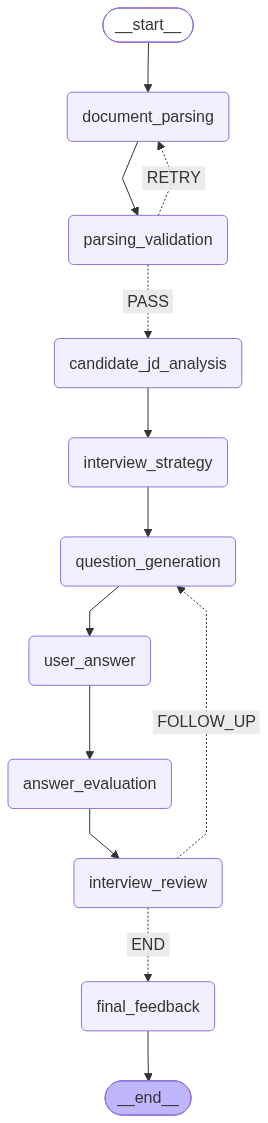

In [174]:
# ============================================================
# 12-3. 전체 LangGraph 연결 구조 시각화
# ============================================================

from IPython.display import Image, display

graph_view = interview_graph.get_graph()

try:
    display(Image(graph_view.draw_mermaid_png()))
except Exception as exc:
    print(f"그래프 이미지 생성 실패: {exc}")
    print("\n=== [LangGraph Mermaid 연결 구조] ===")
    print(graph_view.draw_mermaid())

In [175]:
# ============================================================
# 12-4. 실제 사용자 답변 기반 인터뷰 실행
# ============================================================

import uuid


def run_interview_interactively(
    resume_file_path: str,
    job_posting_url: str,
    thread_id: Optional[str] = None,
) -> InterviewState:
    """질문을 출력하고 사용자 답변을 받아 전체 인터뷰를 실행한다."""
    if not resume_file_path or not job_posting_url:
        raise ValueError("이력서 PDF 경로와 채용공고 URL이 필요합니다.")

    active_thread_id = thread_id or f"interview-{uuid.uuid4()}"
    print(f"인터뷰 세션 ID: {active_thread_id}")
    config = {
        "configurable": {"thread_id": active_thread_id},
        # 여러 질문과 답변이 반복되므로 기본값보다 크게 설정한다.
        "recursion_limit": 200,
    }

    result = interview_graph.invoke(
        {
            "resume_file_path": resume_file_path,
            "job_posting_url": job_posting_url,
        },
        config=config,
    )

    while "__interrupt__" in result:
        interrupt_info = result["__interrupt__"][0].value
        question = interrupt_info.get("question", "현재 질문이 없습니다.")
        competency = interrupt_info.get("competency", "")
        question_type = interrupt_info.get("question_type", "")

        print("\n" + "=" * 60)
        print(f"질문 유형: {question_type}")
        print(f"평가 역량: {competency}")
        print(f"면접관: {question}")

        answer = input("지원자 답변: ").strip()
        while not answer:
            print("답변이 비어 있습니다. 내용을 입력해 주세요.")
            answer = input("지원자 답변: ").strip()

        print(f"지원자 답변: {answer}")
        print("=" * 60)

        result = interview_graph.invoke(
            Command(resume={"answer": answer}),
            config=config,
        )

    print("\n" + "=" * 60)
    print("인터뷰가 종료되었습니다.")
    print(f"종료 사유: {result.get('end_reason') or '완료'}")

    final_feedback = result.get("final_feedback", {})
    if final_feedback:
        print("\n=== 최종 피드백 요약 ===")
        if final_feedback.get("overall_summary"):
            print(final_feedback["overall_summary"])
        if final_feedback.get("overall_score") is not None:
            print(f"전체 점수: {final_feedback['overall_score']}점")

    return result


# 실제 실행 예시
final_interview_result = run_interview_interactively(
    resume_file_path="data/incrut_sample.pdf",
    job_posting_url="https://www.saramin.co.kr/zf_user/jobs/relay/view?rec_idx=54940771",
)


인터뷰 세션 ID: interview-f243cebd-a1dc-4998-8fbe-cb8ddafb2715

질문 유형: INITIAL
평가 역량: AI 기술 적용 능력
면접관: AI 기술을 실제 서비스에 적용한 경험에 대해 구체적으로 설명해 주실 수 있나요?
지원자 답변: KT 에이블스쿨 프로젝트에서 현업 도메인의 복잡한 업무 프로세스를 분석해 실제 사용자 페인포인트를 정의하고, 이를 RAG 및 에이전트 기반의 자동화 파이프라인 기능으로 구체화하여 실무 적용 가능한 완성도 높은 AI 서비스를 구현했습니다.

질문 유형: FOLLOW_UP
평가 역량: AI 기술 적용 능력
면접관: KT 에이블스쿨 프로젝트에서 구현한 AI 서비스의 구체적인 성과나 결과에 대해 말씀해 주실 수 있나요?
지원자 답변: 기존 업무 매뉴얼과 방대한 도메인 문서를 정밀하게 검색·활용할 수 있도록 하이브리드 검색(키워드 BM25 + 벡터 유사도)과 리랭킹 파이프라인을 설계하고, 모델 출력의 신뢰성을 보장하기 위해 Structured Outputs 기반의 검증 체계를 단계별로 구축하여 할루시네이션을 최소화하고 실무 적용성을 확보했습니다.

질문 유형: FOLLOW_UP
평가 역량: AI 기술 적용 능력
면접관: KT 에이블스쿨 프로젝트에서 구축한 검증 체계가 실제로 어떤 성과를 가져왔는지, 구체적인 수치나 사례를 통해 설명해 주실 수 있나요?
지원자 답변: 단순 벡터 검색 대비 도메인 전문 용어와 특정 식별 번호에 대한 검색 누락을 크게 줄여 검색 정확도(Precision@K)를 크게 끌어올렸으며, 리랭커를 통해 상위 노출 문서의 맥락 일치도를 높여 할루시네이션 발생률을 낮추고 현업 실무자가 원하는 정확한 근거 기반 답변을 얻는 소요 시간을 대폭 단축했습니다.

질문 유형: NEXT
평가 역량: 문서화 및 가이드라인 작성 능력
면접관: 문서화 작업에서 어떤 역할을 맡았고, 그 과정에서 어떤 기여를 했는지 구체적으로 설명해 주실 수 있나요?
지원자 답변: 프로젝트 아키텍처 설계와 기술 스택 도입